# [Step 1] 대리 모델(Surrogate)을 통한 데이터 증강 — v2 (Improved)

> **목표:** ~900개의 생존 시뮬레이션 데이터에서 300초 시계열의 **'절댓값 Max Peak(부호 유지)'**를 추출하고,  
> XGBoost 대리 모델을 학습하여 **10만 개의 가상 P1~P6 조합**에 대한 응력/변형 결과를 예측합니다.

---

### v2 개선 사항
| 항목 | v1 (기존) | v2 (개선) |
|------|-----------|----------|
| 마스터 매칭 | Row_ID 컬럼 의존 | 행 인덱스 기반 자동 매칭 (실제 DOE 구조 반영) |
| 모델 학습 | MultiOutputRegressor 래핑 | **타겟별 개별 XGBoost** (하이퍼파라미터 독립 튜닝 가능) |
| 검증 | 단순 Train/Test Split | **5-Fold CV** + 홀드아웃 테스트 병행 |
| EDA | 없음 | 피크 분포, 상관관계 히트맵, Pred vs Actual 산점도 |
| 이상치 검증 | 없음 | 예측된 가상 데이터의 물리적 범위 이탈 경고 |
| 난수 생성 | 균일분포 | **Latin Hypercube Sampling (LHS)** 옵션 추가 |
| 주석 | 최소 | 모든 셀 상세 주석 |

---

### 핵심 물리 로직: '절댓값 Max Peak' 추출
열 사이클링에서 응력은 가열 시 (+), 냉각 시 (-) 방향으로 진동합니다.  
**단순 max()를 쓰면 냉각 시 압축 응력(음수)의 위험성을 놓칩니다.**  
따라서 `abs().idxmax()`로 절댓값이 가장 큰 시점을 찾되, 그 시점의 **원래 부호를 보존**합니다.

```python
# 절댓값이 가장 큰 시점의 인덱스 -> 해당 시점의 원본 값(부호 유지)
max_abs_idx = df_time[col].abs().idxmax()
peak_value  = df_time.loc[max_abs_idx, col]   # 예: -30 (압축 피크)
```

---
## 0. 환경 설정 및 라이브러리 로드

In [2]:
import os
import re
import glob
import time
import warnings
import numpy as np
import pandas as pd
import xgboost as xgb
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings('ignore')  # XGBoost deprecation 경고 억제
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 9

# ====================================================================
# [사용자 설정] 아래 경로만 본인 환경에 맞게 수정하세요
# ====================================================================
CSV_FOLDER = r'C:/Users/alstj/OneDrive/문서/GitHub/Flipchip_surrogate/JMS/data'   # 시계열 CSV들이 저장된 폴더
MASTER_CSV = r'Master_DOE_1200.csv'                  # P1~P6 설계변수 마스터 파일

# 추출 대상 Y 변수 15개 (Time, TempBase 제외)
# 각 변수의 물리적 의미를 주석으로 명시
Y_COLUMNS = [
    'WarpMax',          # 패키지 전체 최대 열변형량 (최소화 메인 타겟 #1)
    'T_Tip_Peel',       # Top 계면 끝단 수직응력 - 박리(Delamination) 원인 (최소화 메인 타겟 #2)
    'T_Tip_Shear',      # Top 계면 끝단 전단응력 - 계면 피로(Fatigue) 유발
    'T_Tip_SEQV',       # Top 끝단 Von Mises 등가응력 - 소성 변형 유발
    'T_Tip_Strain',     # Top 끝단 변형률
    'T_Avg_Peel',       # Top 접합면 평균 수직응력 - 중앙부 Void 유발
    'T_Avg_Shear',      # Top 접합면 평균 전단응력
    'B_Tip_Peel',       # Bottom 끝단 수직응력
    'B_Tip_Shear',      # Bottom 끝단 전단응력
    'B_Tip_SEQV',       # Bottom 끝단 Von Mises 등가응력
    'B_Tip_Strain',     # Bottom 끝단 변형률
    'B_Avg_Peel',       # Bottom 평균 수직응력
    'B_Avg_Shear',      # Bottom 평균 전단응력
    'Die_SX',           # 다이(실리콘 칩) 휨 응력 - Die Crack 유발
    'Die_SY_Max'        # 다이 최대 Y방향 응력 - 모서리 응력 집중
]

# 난수 시드 (재현성 보장)
SEED = 42
np.random.seed(SEED)

print('=== 환경 설정 완료 ===')
print(f'시계열 CSV 폴더 : {CSV_FOLDER}')
print(f'마스터 DOE 파일 : {MASTER_CSV}')
print(f'추출 대상 Y 변수: {len(Y_COLUMNS)}개')

=== 환경 설정 완료 ===
시계열 CSV 폴더 : C:/Users/alstj/OneDrive/문서/GitHub/Flipchip_surrogate/JMS/data
마스터 DOE 파일 : Master_DOE_1200.csv
추출 대상 Y 변수: 15개


---
## 1. 마스터 DOE 로드 및 생존 CSV 탐지

**데이터 구조 (확인 완료):**
- `Master_DOE_1200.csv`: P1~P6 컬럼만 존재 (Row_ID 없음, 1200행)
  - 행 인덱스(0-based) + 1 = Row_ID로 매핑
  - P1: [0.80, 1.10] / P2: [0.05, 0.09] / P3: [0.60, 0.72]
  - P4: [0.10, 0.30] / P5: [1.20, 1.80] / P6: [0.04, 0.08]
- 시계열 파일: `ML_DATA_Extract_Row_{Row_ID}.csv` (617행 x 17열, 0.1~300초)

In [3]:
# == 1-1. 마스터 DOE 로드 ==
# P1~P6만 존재하는 1200행 파일. Row_ID 컬럼이 없으므로 직접 부여함.
df_master = pd.read_csv(MASTER_CSV)

# Row_ID 생성: 행 인덱스 + 1 = CSV 파일명의 Row 번호와 1:1 대응
# 즉, Master CSV의 1번째 행(index=0) -> Row_ID=1 -> ML_DATA_Extract_Row_1.csv
df_master.insert(0, 'Row_ID', range(1, len(df_master) + 1))

print(f'마스터 DOE 로드 완료: {len(df_master)}개 DP (Design Points)')
print(f'컬럼: {list(df_master.columns)}')
print()

# 각 P 변수의 범위 확인 (몬테카를로 생성 시 바운더리로 사용됨)
print('-- P1~P6 실제 범위 --')
for col in ['P1','P2','P3','P4','P5','P6']:
    print(f'  {col}: [{df_master[col].min():.4f}, {df_master[col].max():.4f}]')

display(df_master.head())

마스터 DOE 로드 완료: 1200개 DP (Design Points)
컬럼: ['Row_ID', 'P1', 'P2', 'P3', 'P4', 'P5', 'P6']

-- P1~P6 실제 범위 --
  P1: [0.8005, 1.0998]
  P2: [0.0500, 0.0899]
  P3: [0.6001, 0.7198]
  P4: [0.1000, 0.2994]
  P5: [1.2003, 1.7997]
  P6: [0.0401, 0.0800]


,Row_ID,P1,P2,P3,P4,P5,P6
0,1,0.8317,0.0842,0.6021,0.1075,1.7454,0.0585
1,2,0.8143,0.0777,0.7136,0.1333,1.4174,0.0696
2,3,0.8013,0.0512,0.6363,0.2312,1.3751,0.0560
3,4,1.0509,0.0569,0.6031,0.2220,1.2660,0.0777
4,5,0.8744,0.0670,0.6206,0.2669,1.4158,0.0779


In [4]:
# == 1-2. 생존 CSV 파일 자동 탐지 ==
# 폴더를 스캔하여 실제 존재하는 시계열 파일의 Row_ID를 파싱
# (시뮬레이션이 터진 DP는 CSV 파일 자체가 생성되지 않음)

# glob으로 해당 폴더의 모든 ML_DATA_Extract_Row_*.csv 파일 탐색
pattern = os.path.join(CSV_FOLDER, 'ML_DATA_Extract_Row_*.csv')
found_files = sorted(glob.glob(pattern))

# 파일명에서 Row_ID 숫자를 정규식으로 추출
survived_ids = []
for fpath in found_files:
    fname = os.path.basename(fpath)
    match = re.search(r'Row_(\d+)\.csv', fname)
    if match:
        survived_ids.append(int(match.group(1)))

survived_ids = sorted(survived_ids)

# 생존 통계 출력
n_total = len(df_master)
n_alive = len(survived_ids)
n_dead  = n_total - n_alive

print(f'전체 DP      : {n_total}개')
print(f'생존 CSV     : {n_alive}개 ({n_alive/n_total*100:.1f}%)')
print(f'결측(터진) DP: {n_dead}개 ({n_dead/n_total*100:.1f}%)')
print(f'생존 Row_ID 범위: {min(survived_ids)} ~ {max(survived_ids)}')

전체 DP      : 1200개
생존 CSV     : 556개 (46.3%)
결측(터진) DP: 644개 (53.7%)
생존 Row_ID 범위: 1 ~ 857


---
## 2. 시계열 데이터에서 '절댓값 Max Peak' 추출 (Feature Extraction)

각 생존 CSV(300초, 617 timestep)에서 15개 Y 채널별로:
1. `abs().idxmax()` -> 절댓값이 최대인 시간 인덱스 탐색
2. 해당 시점의 원본 값(부호 유지)을 피크로 기록

결과: **[Row_ID, P1~P6, Y1_peak ~ Y15_peak]** 형태의 정적 데이터셋 구축

In [6]:
# == 2-1. 생존 데이터 순회 및 Max Peak 추출 ==

valid_data = []     # 정상 추출된 데이터를 누적할 리스트
error_rows = []     # 읽기 오류가 발생한 Row_ID를 기록할 리스트

t_start = time.time()
print(f'{len(survived_ids)}개 생존 CSV에서 Max Peak 추출 시작...')

for i, row_id in enumerate(survived_ids):
    # 시계열 CSV 파일 경로 구성
    fpath = os.path.join(CSV_FOLDER, f'ML_DATA_Extract_Row_{row_id}.csv')
    
    try:
        # 시계열 데이터 로드 (617행 x 17열: Time, TempBase, 15 Y변수)
        df_ts = pd.read_csv(fpath)
        
        # 컬럼명 앞뒤 공백 제거 (CSV 헤더에 공백 포함될 수 있음)
        df_ts.columns = [c.strip() for c in df_ts.columns]
        
        # 마스터 DOE에서 해당 Row의 P1~P6 가져오기
        # Row_ID는 1-based이므로, df_master에서 Row_ID == row_id인 행을 찾음
        master_row = df_master[df_master['Row_ID'] == row_id]
        if master_row.empty:
            error_rows.append((row_id, 'Master DOE에 해당 Row_ID 없음'))
            continue
        
        # 결과 딕셔너리 초기화
        peak_dict = {'Row_ID': row_id}
        
        # P1~P6 설계변수 값 저장
        for p_col in ['P1','P2','P3','P4','P5','P6']:
            peak_dict[p_col] = master_row[p_col].values[0]
        
        # === 핵심 로직: 각 Y 채널별 '절댓값 최대 피크(부호 유지)' 추출 ===
        for y_col in Y_COLUMNS:
            if y_col in df_ts.columns:
                # Step A: 300초 시계열에서 절댓값이 가장 큰 시간 인덱스 탐색
                #   abs()로 절댓값을 취한 뒤 idxmax()로 최대 위치를 찾음
                max_abs_idx = df_ts[y_col].abs().idxmax()
                
                # Step B: 해당 시점의 원래 값(부호 보존)을 피크로 기록
                #   예) 시계열이 [+10, -30, +20]이면:
                #       abs = [10, 30, 20] -> idxmax = 1 -> 원본값 = -30
                #   이렇게 해야 냉각 시 압축 응력의 위험성을 놓치지 않음
                peak_dict[y_col] = df_ts.loc[max_abs_idx, y_col]
            else:
                # 해당 Y 컬럼이 CSV에 없는 경우 NaN 처리
                peak_dict[y_col] = np.nan
        
        valid_data.append(peak_dict)
        
    except Exception as e:
        error_rows.append((row_id, str(e)))
    
    # 진행률 표시 (200개마다)
    if (i + 1) % 200 == 0:
        print(f'  ... {i+1}/{len(survived_ids)} 처리 완료')

elapsed = time.time() - t_start

# 결과 취합
df_peaks = pd.DataFrame(valid_data)

print(f'\n=== Max Peak 추출 완료 ===')
print(f'성공: {len(df_peaks)}개 / 실패: {len(error_rows)}개 / 소요시간: {elapsed:.1f}초')

if error_rows:
    print(f'\n[경고] 오류 발생 Row (처음 5개): {error_rows[:5]}')

# NaN이 있는 행 확인 및 제거
nan_count = df_peaks[Y_COLUMNS].isnull().any(axis=1).sum()
if nan_count > 0:
    print(f'[경고] {nan_count}개 행에 NaN 존재 -> 해당 행 제거')
    df_peaks = df_peaks.dropna(subset=Y_COLUMNS).reset_index(drop=True)

print(f'\n최종 학습용 데이터: {len(df_peaks)}개')
display(df_peaks.head())

556개 생존 CSV에서 Max Peak 추출 시작...
  ... 200/556 처리 완료
  ... 400/556 처리 완료

=== Max Peak 추출 완료 ===
성공: 556개 / 실패: 0개 / 소요시간: 1.8초

최종 학습용 데이터: 556개


,Row_ID,P1,P2,P3,P4,P5,P6,WarpMax,T_Tip_Peel,T_Tip_Shear,...,T_Avg_Peel,T_Avg_Shear,B_Tip_Peel,B_Tip_Shear,B_Tip_SEQV,B_Tip_Strain,B_Avg_Peel,B_Avg_Shear,Die_SX,Die_SY_Max
0,1,0.8317,0.0842,0.6021,0.1075,1.7454,0.0585,-0.107084,-34.039048,-8.025589,...,0.023255,-3.071933,-5.445917,-2.957903,28.329506,0.002043,0.032548,-2.861042,66.203874,-85.012494
1,2,0.8143,0.0777,0.7136,0.1333,1.4174,0.0696,-0.144790,-31.629051,8.315480,...,0.031333,-2.707141,-4.092614,-2.676881,25.607135,0.001761,0.025406,-2.568996,63.021576,-87.551451
2,4,1.0509,0.0569,0.6031,0.2220,1.2660,0.0777,-0.158005,-38.879585,8.994357,...,0.084601,-2.668019,-4.944124,-2.822713,29.147154,0.001970,-0.027274,-2.938019,61.316208,-86.130069
3,5,0.8744,0.0670,0.6206,0.2669,1.4158,0.0779,-0.138039,-33.084874,8.631955,...,0.031446,-2.621313,-4.015564,-2.296843,26.291782,0.001684,-0.015385,-2.606656,58.891827,-81.062810
4,7,0.9347,0.0506,0.6789,0.1163,1.6356,0.0661,-0.120482,-41.494301,8.232958,...,0.081118,-2.695119,-5.653280,-2.729163,32.351288,0.002114,0.010124,-2.795657,58.882464,-89.189848


---
## 3. 탐색적 데이터 분석 (EDA)

학습 전 데이터의 분포와 상관관계를 시각화하여 이상 패턴을 사전 진단합니다.

In [7]:
# == 3-1. Y 변수 기술 통계 ==
print('=== Y 변수 기술 통계 (Max Peak 기준) ===')
display(df_peaks[Y_COLUMNS].describe().round(4))

=== Y 변수 기술 통계 (Max Peak 기준) ===


,WarpMax,T_Tip_Peel,T_Tip_Shear,T_Tip_SEQV,T_Tip_Strain,T_Avg_Peel,T_Avg_Shear,B_Tip_Peel,B_Tip_Shear,B_Tip_SEQV,B_Tip_Strain,B_Avg_Peel,B_Avg_Shear,Die_SX,Die_SY_Max
count,556.0000,556.0000,556.0000,556.0000,556.0000,556.0000,556.0000,556.0000,556.0000,556.0000,556.0000,556.0000,556.0000,556.0000,556.0000
mean,-0.1365,-35.4010,7.6001,38.0651,0.0035,0.0320,-2.8785,-5.8776,-2.7589,28.3653,0.0020,-0.0024,-2.8769,62.5418,-88.2653
std,0.0186,2.9070,4.3934,3.4726,0.0003,0.0302,0.3222,2.0743,0.4875,2.0087,0.0002,0.0198,0.2934,4.0206,5.6853
min,-0.1728,-47.2917,-13.0566,30.9377,0.0028,-0.0280,-5.2160,-11.1823,-6.0878,23.2101,0.0015,-0.0677,-5.2635,57.7090,-104.0513
25%,-0.1516,-37.2247,8.1763,35.7023,0.0033,0.0108,-2.9999,-7.0868,-3.0298,26.9094,0.0018,-0.0164,-2.9818,59.7354,-92.6094
50%,-0.1356,-35.2657,8.6042,37.7430,0.0035,0.0275,-2.7973,-5.7665,-2.7179,28.1878,0.0020,-0.0050,-2.8182,61.1848,-87.8707
75%,-0.1210,-33.2705,9.0448,39.8665,0.0037,0.0563,-2.6863,-4.7850,-2.4334,29.5422,0.0021,0.0138,-2.6857,64.3295,-84.1066
max,-0.1025,-28.7603,10.6679,56.8349,0.0049,0.1454,-2.4083,11.6636,-1.7034,38.1656,0.0031,0.0373,-2.3874,87.9883,-72.2885


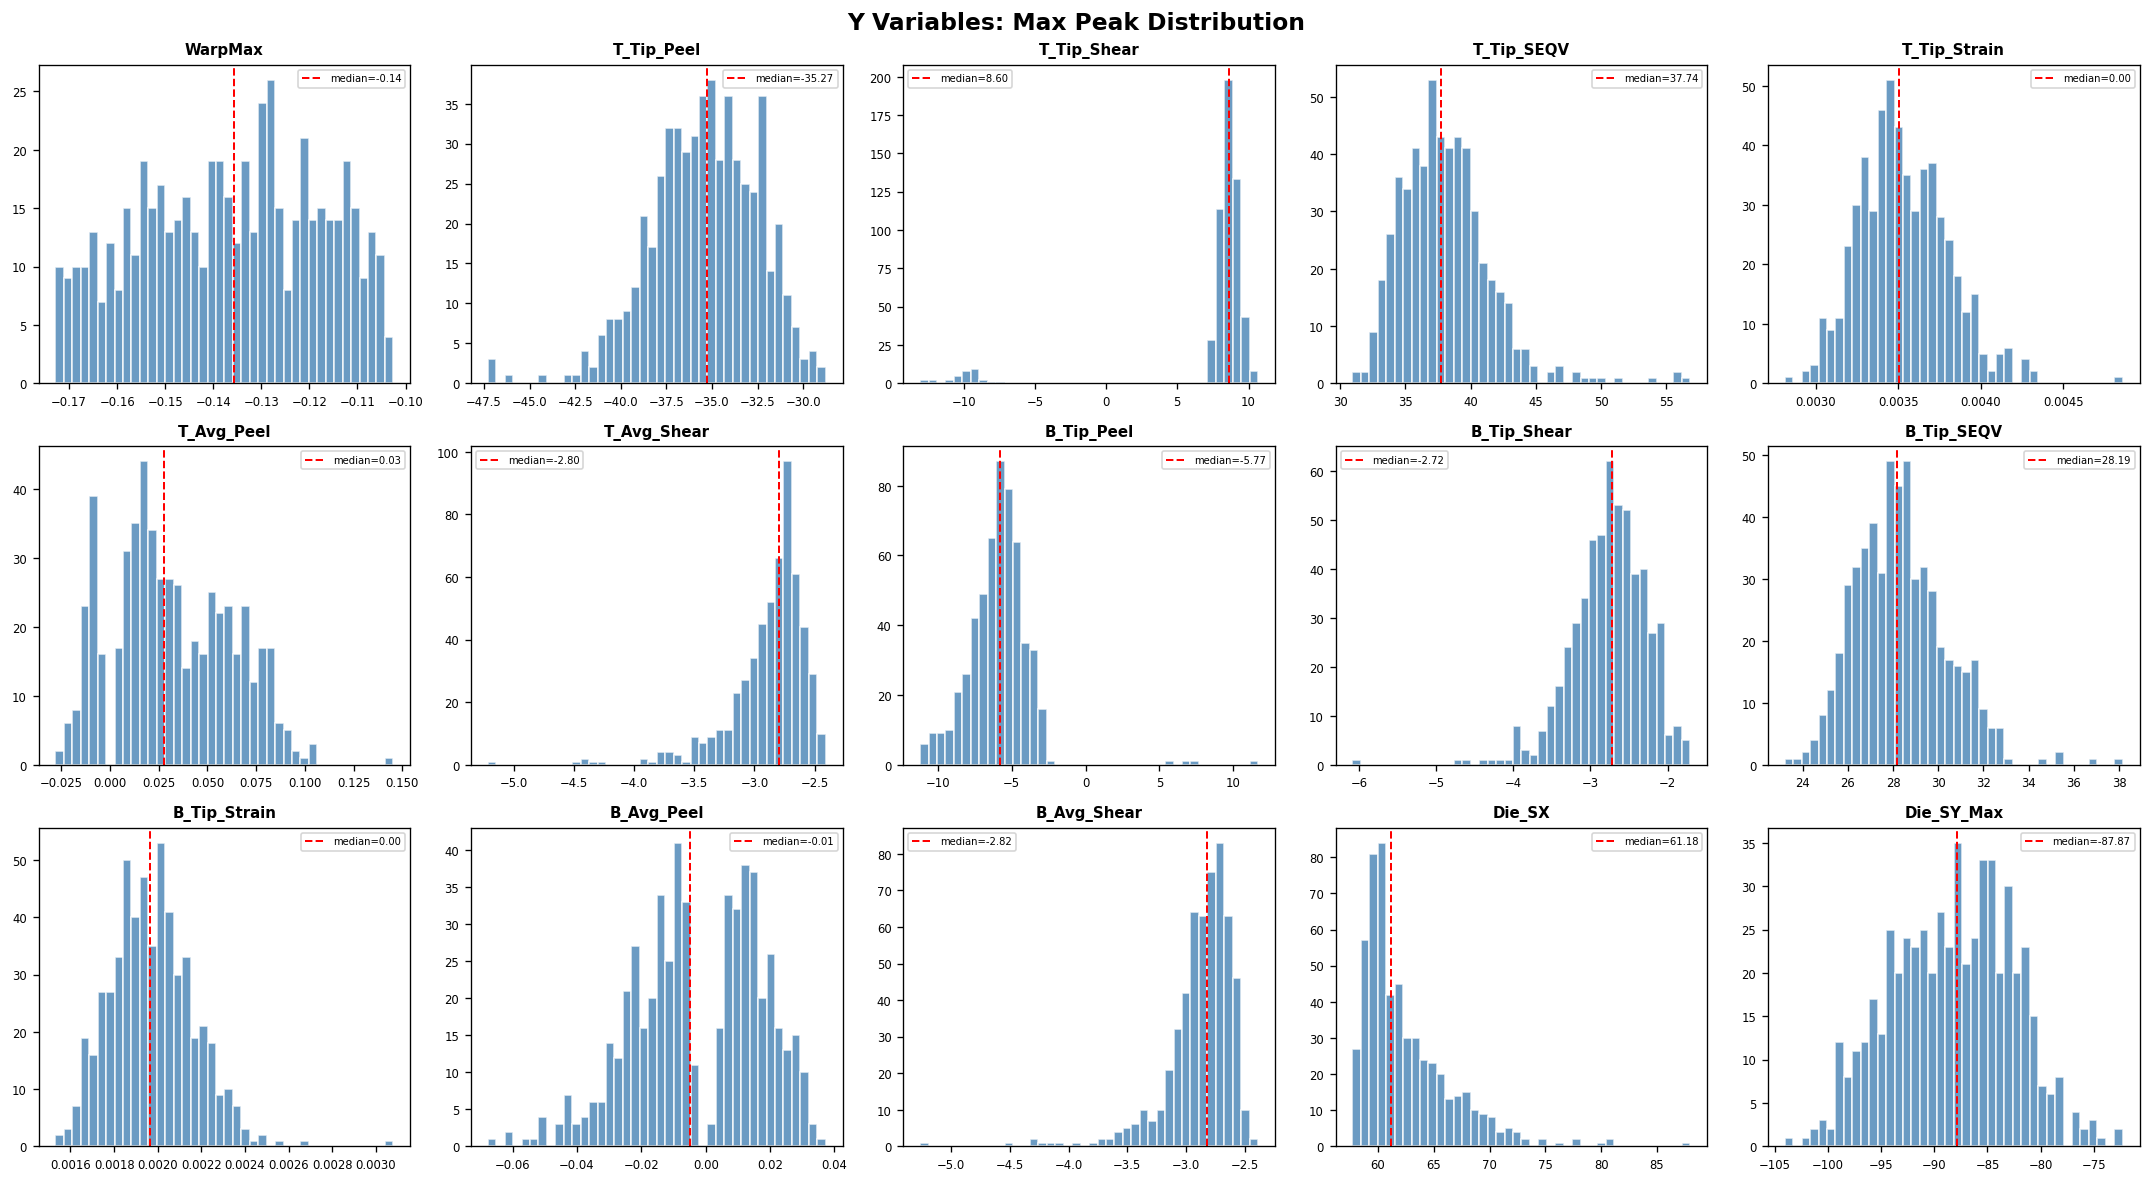

In [8]:
# == 3-2. Y 변수 피크값 분포 히스토그램 ==
# 각 응력/변형 채널의 피크 분포를 확인하여 편향(skew)이나 이상치 진단

fig, axes = plt.subplots(3, 5, figsize=(18, 10))
fig.suptitle('Y Variables: Max Peak Distribution', fontsize=14, fontweight='bold')

for idx, y_col in enumerate(Y_COLUMNS):
    ax = axes[idx // 5, idx % 5]
    data = df_peaks[y_col].dropna()
    
    # 히스토그램 + 중앙값 표시
    ax.hist(data, bins=40, color='steelblue', edgecolor='white', alpha=0.8)
    ax.axvline(data.median(), color='red', linewidth=1.2, linestyle='--',
               label=f'median={data.median():.2f}')
    ax.set_title(y_col, fontsize=9, fontweight='bold')
    ax.legend(fontsize=6)
    ax.tick_params(labelsize=7)

plt.tight_layout()
plt.show()

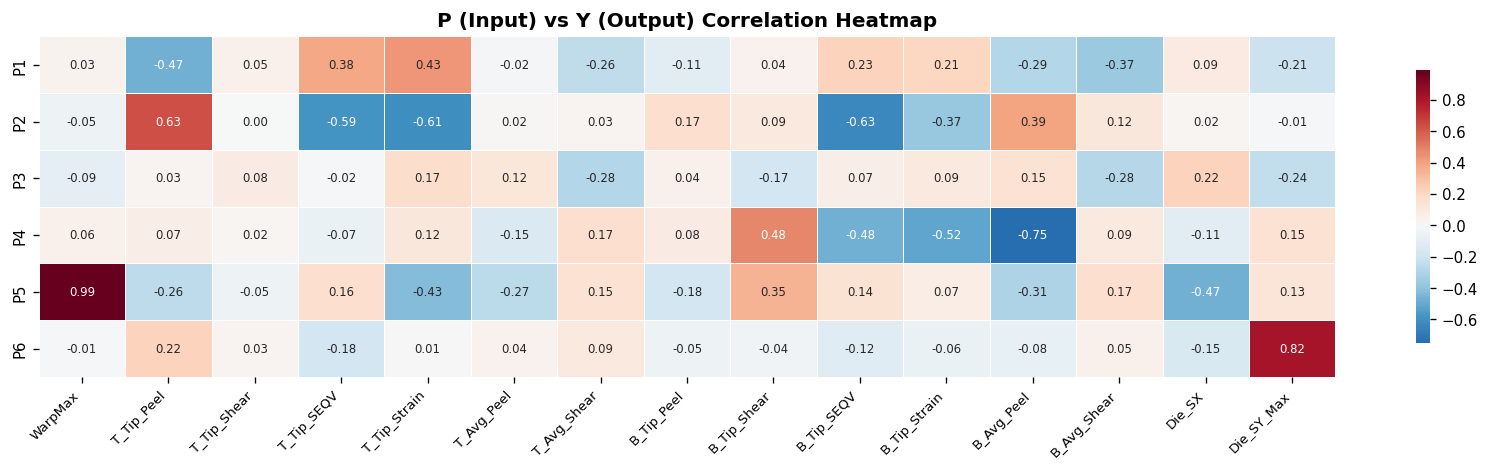


-- |상관계수| > 0.5인 강한 P-Y 관계 --
  P2 -> T_Tip_Peel: r=0.633 (양의 상관)
  P2 -> T_Tip_SEQV: r=-0.592 (음의 상관)
  P2 -> T_Tip_Strain: r=-0.608 (음의 상관)
  P2 -> B_Tip_SEQV: r=-0.629 (음의 상관)
  P4 -> B_Tip_Strain: r=-0.517 (음의 상관)
  P4 -> B_Avg_Peel: r=-0.751 (음의 상관)
  P5 -> WarpMax: r=0.987 (양의 상관)
  P6 -> Die_SY_Max: r=0.823 (양의 상관)


In [9]:
# == 3-3. P(입력) <-> Y(출력) 상관관계 히트맵 ==
# 어떤 두께 변수(P)가 어떤 응력(Y)에 강하게 영향을 미치는지 파악

p_cols = ['P1','P2','P3','P4','P5','P6']
corr_matrix = df_peaks[p_cols + Y_COLUMNS].corr()

# P vs Y 영역만 추출 (6 x 15 부분행렬)
corr_py = corr_matrix.loc[p_cols, Y_COLUMNS]

fig, ax = plt.subplots(figsize=(14, 4))
sns.heatmap(corr_py, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            linewidths=0.5, ax=ax, annot_kws={'size': 7},
            cbar_kws={'shrink': 0.8})
ax.set_title('P (Input) vs Y (Output) Correlation Heatmap', fontsize=12, fontweight='bold')
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=8)
plt.tight_layout()
plt.show()

# 상관관계가 강한 P-Y 조합 출력 (|r| > 0.5)
print('\n-- |상관계수| > 0.5인 강한 P-Y 관계 --')
for p in p_cols:
    for y in Y_COLUMNS:
        r = corr_py.loc[p, y]
        if abs(r) > 0.5:
            direction = '양' if r > 0 else '음'
            print(f'  {p} -> {y}: r={r:.3f} ({direction}의 상관)')

---
## 4. XGBoost 대리 모델 학습

### 학습 전략
- **타겟별 개별 XGBoost** 학습 (각 타겟의 하이퍼파라미터를 독립 튜닝 가능)
- **5-Fold Cross Validation**으로 과적합 여부 진단
- **홀드아웃 Test Set (15%)**으로 최종 성능 평가
- **Early Stopping**: validation loss가 20 라운드 연속 개선 안 되면 조기 종료

### 하이퍼파라미터 선정 근거
- `n_estimators=300`: ~900개 중간 규모 데이터에 충분한 앙상블 수
- `max_depth=6`: 6개 입력변수 대비 적절한 트리 깊이
- `learning_rate=0.05`: 보수적 학습률로 과적합 방지
- `subsample/colsample_bytree=0.8`: 랜덤 서브샘플링으로 일반화 향상
- `reg_alpha=0.1, reg_lambda=1.0`: L1/L2 정규화로 복잡도 억제

기존 타겟 수: 15개
제외된 타겟: ['T_Tip_Shear', 'T_Avg_Shear', 'T_Avg_Peel', 'B_Tip_Peel']
최종 학습 타겟 수: 11개
전체 데이터: 556개 | Train: 472개 | Test: 84개
전체 데이터: 556개 | Train: 472개 | Test: 84개

=== 타겟별 Optuna 최적화 및 LightGBM 학습 시작 ===
--- Optimizing WarpMax ---


Exception in thread Thread-5 (_readerthread):
Traceback (most recent call last):
  File "c:\Users\alstj\miniconda3\envs\DL\Lib\threading.py", line 1045, in _bootstrap_inner
    self.run()
  File "c:\Users\alstj\miniconda3\envs\DL\Lib\threading.py", line 982, in run
    self._target(*self._args, **self._kwargs)
  File "c:\Users\alstj\miniconda3\envs\DL\Lib\subprocess.py", line 1599, in _readerthread
    buffer.append(fh.read())
                  ^^^^^^^^^
  File "<frozen codecs>", line 322, in decode
UnicodeDecodeError: 'utf-8' codec can't decode byte 0xc0 in position 4: invalid start byte


Training until validation scores don't improve for 20 rounds
Did not meet early stopping. Best iteration is:
[773]	valid_0's rmse: 0.00118963	valid_0's l2: 1.41522e-06
  Done! [Best CV R2: 0.9960] [Test R2: 0.9967]
--- Optimizing T_Tip_Peel ---
Training until validation scores don't improve for 20 rounds
Early stopping, best iteration is:
[352]	valid_0's rmse: 1.41111	valid_0's l2: 1.99123
  Done! [Best CV R2: 0.6887] [Test R2: 0.6249]
--- Optimizing T_Tip_SEQV ---
Training until validation scores don't improve for 20 rounds
Did not meet early stopping. Best iteration is:
[172]	valid_0's rmse: 2.22219	valid_0's l2: 4.93812
  Done! [Best CV R2: 0.5142] [Test R2: 0.4358]
--- Optimizing T_Tip_Strain ---
Training until validation scores don't improve for 20 rounds
Early stopping, best iteration is:
[605]	valid_0's rmse: 0.000133598	valid_0's l2: 1.78484e-08
  Done! [Best CV R2: 0.7650] [Test R2: 0.8128]
--- Optimizing B_Tip_Shear ---
Training until validation scores don't improve for 20 ro

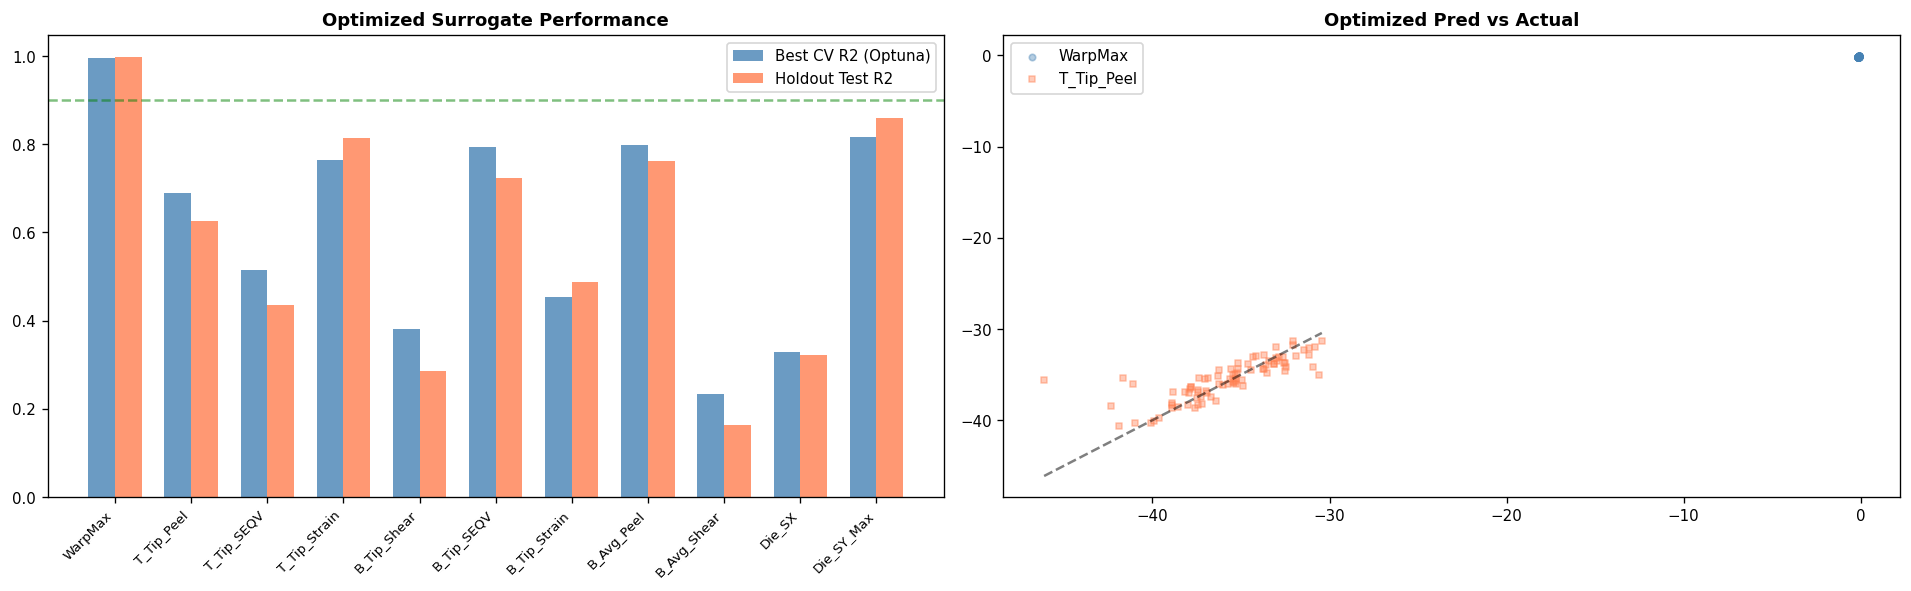

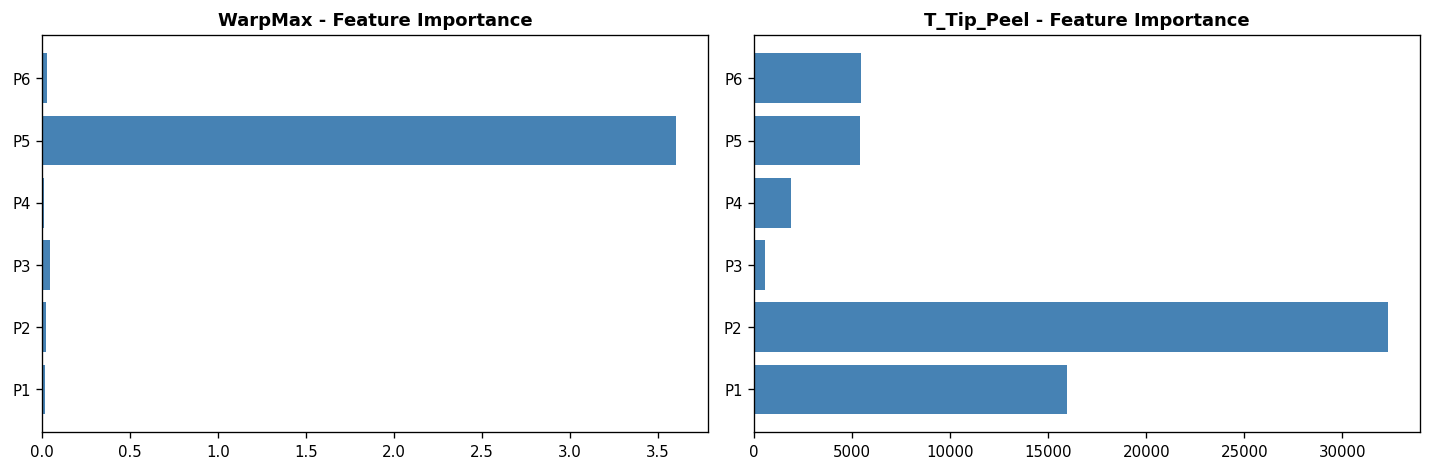

In [10]:
import lightgbm as lgb  # XGB 대신 LGBM 임포트
from sklearn.model_selection import KFold, train_test_split, cross_val_score
from sklearn.metrics import r2_score, mean_absolute_error
import matplotlib.pyplot as plt
import numpy as np
import time
import optuna

# Optuna 로그 설정
optuna.logging.set_verbosity(optuna.logging.WARNING)

# == 4-1. X / Y 분리 및 Train / Test Split ==
#X = df_peaks[['P1','P2','P3','P4','P5','P6']].copy() 
#Y = df_peaks[Y_COLUMNS].copy() 

# == 4-1. 제외할 컬럼 리스트 정의 ==
exclude_cols = ['T_Tip_Shear', 'T_Avg_Shear', 'T_Avg_Peel', 'B_Tip_Peel']

# 기존 Y_COLUMNS에서 위 리스트에 포함되지 않은 것만 필터링
# (Y_COLUMNS가 이미 정의되어 있다고 가정)
Y_COLUMNS_FILTERED = [col for col in Y_COLUMNS if col not in exclude_cols]

print(f"기존 타겟 수: {len(Y_COLUMNS)}개")
print(f"제외된 타겟: {exclude_cols}")
print(f"최종 학습 타겟 수: {len(Y_COLUMNS_FILTERED)}개")

# == X / Y 분리 및 Train / Test Split ==
X = df_peaks[['P1','P2','P3','P4','P5','P6']].copy() 
Y = df_peaks[Y_COLUMNS_FILTERED].copy()  # 필터링된 컬럼만 사용

# 최종 성능 평가용 홀드아웃 세트 (15%)
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.15, random_state=SEED)

print(f'전체 데이터: {len(X)}개 | Train: {len(X_train)}개 | Test: {len(X_test)}개')

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.15, random_state=SEED)

print(f'전체 데이터: {len(X)}개 | Train: {len(X_train)}개 | Test: {len(X_test)}개')

# == 4-2. Optuna 목적 함수 정의 (LGBM 버전) ==
def objective(trial, X_tuning, y_tuning):
    param = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 1000),
        'max_depth': trial.suggest_int('max_depth', 3, 12),
        'num_leaves': trial.suggest_int('num_leaves', 7, 255), # LGBM의 핵심 파라미터
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-3, 10.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-3, 10.0, log=True),
        'min_child_samples': trial.suggest_int('min_child_samples', 5, 100),
        'random_state': SEED,
        'importance_type': 'gain', # XGBoost와 동일한 gain 기준 중요도 계산
        'verbosity': -1,
        'n_jobs': -1
    }
    
    kf = KFold(n_splits=5, shuffle=True, random_state=SEED)
    # LGBMRegressor 사용
    cv_score = cross_val_score(lgb.LGBMRegressor(**param), X_tuning, y_tuning, cv=kf, scoring='r2').mean()
    return cv_score

# == 4-3. 타겟별 개별 최적화 및 학습 수행 ==
models = {}
cv_scores = {}
test_scores = {}
test_maes = {}

print('\n=== 타겟별 Optuna 최적화 및 LightGBM 학습 시작 ===')
t_start = time.time()

for y_col in Y_COLUMNS_FILTERED:
    print(f'--- Optimizing {y_col} ---')
    
    study = optuna.create_study(direction='maximize')
    study.optimize(lambda trial: objective(trial, X_train, Y_train[y_col]), n_trials=30)
    
    X_tr, X_val, y_tr, y_val = train_test_split(X_train, Y_train[y_col], test_size=0.15, random_state=SEED)
    
    # 최종 모델 정의
    best_model = lgb.LGBMRegressor(
        **study.best_params, 
        random_state=SEED,
        importance_type='gain'
    )
    
    # LGBM의 Early Stopping 방식 (callbacks 사용)
    best_model.fit(
        X_tr, y_tr,
        eval_set=[(X_val, y_val)],
        eval_metric='rmse',
        callbacks=[lgb.early_stopping(stopping_rounds=20), lgb.log_evaluation(period=0)]
    )
    
    y_pred = best_model.predict(X_test)
    models[y_col] = best_model
    cv_scores[y_col] = study.best_value
    test_scores[y_col] = r2_score(Y_test[y_col], y_pred)
    test_maes[y_col] = mean_absolute_error(Y_test[y_col], y_pred)
    
    print(f'  Done! [Best CV R2: {cv_scores[y_col]:.4f}] [Test R2: {test_scores[y_col]:.4f}]')

elapsed = time.time() - t_start
print(f'\n=== 전체 최적화 학습 완료 ({elapsed:.1f}초 소요) ===')

# == 4-4. 결과 시각화 (기존 로직 유지) ==
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# (A) 변수별 R2 비교
ax = axes[0]
x_pos = np.arange(len(Y_COLUMNS_FILTERED))
width = 0.35
ax.bar(x_pos - width/2, [cv_scores[c] for c in Y_COLUMNS_FILTERED], width, label='Best CV R2 (Optuna)', color='steelblue', alpha=0.8)
ax.bar(x_pos + width/2, [test_scores[c] for c in Y_COLUMNS_FILTERED], width, label='Holdout Test R2', color='coral', alpha=0.8)
ax.set_xticks(x_pos)
ax.set_xticklabels(Y_COLUMNS_FILTERED, rotation=45, ha='right', fontsize=8)
ax.set_title('Optimized Surrogate Performance', fontweight='bold')
ax.legend()
ax.axhline(0.9, color='green', linestyle='--', alpha=0.5)

# (B) 메인 타겟 Pred vs Actual
ax = axes[1]
for y_col, color, marker in [('WarpMax', 'steelblue', 'o'), ('T_Tip_Peel', 'coral', 's')]:
    ax.scatter(Y_test[y_col], models[y_col].predict(X_test), alpha=0.4, s=15, c=color, marker=marker, label=y_col)
ax.plot([Y_test[y_col].min(), Y_test[y_col].max()], [Y_test[y_col].min(), Y_test[y_col].max()], 'k--', alpha=0.5)
ax.set_title('Optimized Pred vs Actual', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

# (C) Feature Importance
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, y_col in zip(axes, ['WarpMax', 'T_Tip_Peel']):
    importance = models[y_col].feature_importances_
    ax.barh(['P1','P2','P3','P4','P5','P6'], importance, color='steelblue')
    ax.set_title(f'{y_col} - Feature Importance', fontweight='bold')
plt.tight_layout()
plt.show()

In [11]:
print(f"실제 데이터 최소값: {Y_test['WarpMax'].min()}")
print(f"AI 예측 데이터 최소값: {models['WarpMax'].predict(X_test).min()}")

실제 데이터 최소값: -0.165976984
AI 예측 데이터 최소값: -0.16689942581703643


---
## 5. 몬테카를로 난수 생성 및 10만 개 가상 데이터 증강

학습된 XGBoost 대리 모델로 **10만 개의 가상 P1~P6 조합**에 대한 Y값을 예측합니다.

### 난수 생성 방식: Latin Hypercube Sampling (LHS)
- 단순 `np.random.uniform`보다 6차원 설계 공간을 **더 균일하게 커버**
- 각 차원을 N개 구간으로 분할 후 구간당 1개씩 배치 (층화 샘플링)
- 동일 샘플 수 대비 사각지대(dead zone) 없이 골고루 분포

In [12]:
# == 5-1. Latin Hypercube Sampling (LHS)으로 10만 개 P1~P6 생성 ==

N_VIRTUAL = 100_000  # 생성할 가상 데이터 수

def latin_hypercube_sampling(n_samples, n_dims, seed=42):
    """
    Latin Hypercube Sampling (LHS) 구현
    
    원리:
    - [0, 1] 범위를 n_samples개의 균등 구간으로 분할
    - 각 차원에서 한 구간당 정확히 하나의 샘플을 배치 (층화 샘플링)
    - 차원별로 독립적으로 셔플하여 조합
    
    Parameters:
        n_samples: 생성할 샘플 수
        n_dims: 차원 수 (변수 수)
        seed: 난수 시드
    Returns:
        (n_samples, n_dims) numpy 배열, 값 범위 [0, 1]
    """
    rng = np.random.RandomState(seed)
    result = np.zeros((n_samples, n_dims))
    
    for dim in range(n_dims):
        # 각 구간 내에서의 랜덤 오프셋 생성
        perms = rng.permutation(n_samples)  # 구간 순서 셔플
        # (구간 번호 + 랜덤 오프셋) / 총 구간 수 -> [0, 1] 범위로 정규화
        result[:, dim] = (perms + rng.uniform(size=n_samples)) / n_samples
    
    return result

# [0,1]^6 범위 LHS 생성
lhs_raw = latin_hypercube_sampling(N_VIRTUAL, n_dims=6, seed=SEED)

# 각 P 변수의 실제 min/max 바운더리로 스케일링
# 바운더리는 마스터 DOE 전체 1200개 기준 (생존 데이터가 아닌 원본 전체)
p_cols = ['P1','P2','P3','P4','P5','P6']
virtual_X_dict = {}

print(f'-- {N_VIRTUAL:,}개 가상 P1~P6 생성 (LHS) --')
print(f'{"변수":>5s} | {"Min":>8s} | {"Max":>8s}')
print('-' * 30)

for i, p in enumerate(p_cols):
    lo = df_master[p].min()   # 마스터 DOE 전체의 최솟값
    hi = df_master[p].max()   # 마스터 DOE 전체의 최댓값
    
    # [0,1] -> [min, max] 선형 변환
    virtual_X_dict[p] = lo + (hi - lo) * lhs_raw[:, i]
    print(f'{p:>5s} | {lo:8.4f} | {hi:8.4f}')

df_virtual_X = pd.DataFrame(virtual_X_dict)
print(f'\n{N_VIRTUAL:,}개 가상 P1~P6 조합 생성 완료')
display(df_virtual_X.describe().round(4))

-- 100,000개 가상 P1~P6 생성 (LHS) --
   변수 |      Min |      Max
------------------------------
   P1 |   0.8005 |   1.0998
   P2 |   0.0500 |   0.0899
   P3 |   0.6001 |   0.7198
   P4 |   0.1000 |   0.2994
   P5 |   1.2003 |   1.7997
   P6 |   0.0401 |   0.0800

100,000개 가상 P1~P6 조합 생성 완료


,P1,P2,P3,P4,P5,P6
count,100000.0000,100000.0000,100000.0000,100000.0000,100000.0000,100000.0000
mean,0.9502,0.0699,0.6600,0.1997,1.5000,0.0600
std,0.0864,0.0115,0.0346,0.0576,0.1730,0.0115
min,0.8005,0.0500,0.6001,0.1000,1.2003,0.0401
25%,0.8753,0.0600,0.6300,0.1499,1.3502,0.0501
50%,0.9502,0.0700,0.6599,0.1997,1.5000,0.0600
75%,1.0250,0.0799,0.6899,0.2495,1.6498,0.0700
max,1.0998,0.0899,0.7198,0.2994,1.7997,0.0800


In [13]:
# == 5-2. 대리 모델로 10만 개 Y값 동시 예측 ==

print(f'학습된 XGBoost로 {N_VIRTUAL:,}개의 Y 값 예측 중...')
t_start = time.time()

virtual_Y_dict = {}
for y_col in Y_COLUMNS_FILTERED:
    # 각 타겟별로 학습된 개별 모델로 예측
    virtual_Y_dict[y_col] = models[y_col].predict(df_virtual_X)

df_virtual_Y = pd.DataFrame(virtual_Y_dict)

elapsed = time.time() - t_start
print(f'예측 완료! ({elapsed:.2f}초 소요)')

학습된 XGBoost로 100,000개의 Y 값 예측 중...
예측 완료! (2.04초 소요)


In [15]:
# == 5-3. 예측 결과 물리적 범위 검증 ==
# 대리 모델이 외삽(extrapolation)하여 비현실적인 값을 예측했는지 검증
# 실제 데이터 범위 +- 20% 마진을 허용 범위로 설정

print('=== 예측 데이터 물리적 범위 검증 ===')
print(f'{"변수":15s} | {"실제 Min":>12s} | {"실제 Max":>12s} | '
      f'{"예측 Min":>12s} | {"예측 Max":>12s} | 이탈률')
print('-' * 90)

outlier_flags = pd.Series(False, index=df_virtual_Y.index)

for y_col in Y_COLUMNS_FILTERED:
    actual_min = df_peaks[y_col].min()
    actual_max = df_peaks[y_col].max()
    pred_min = df_virtual_Y[y_col].min()
    pred_max = df_virtual_Y[y_col].max()
    
    # 실제 범위의 20% 마진을 허용 범위로 설정
    margin = (actual_max - actual_min) * 0.20
    safe_lo = actual_min - margin
    safe_hi = actual_max + margin
    
    # 허용 범위를 벗어나는 예측값 탐지
    out_mask = (df_virtual_Y[y_col] < safe_lo) | (df_virtual_Y[y_col] > safe_hi)
    outlier_flags = outlier_flags | out_mask
    n_out = out_mask.sum()
    pct = n_out / len(df_virtual_Y) * 100
    
    flag = '  <<' if pct > 5 else ''
    print(f'{y_col:15s} | {actual_min:12.4f} | {actual_max:12.4f} | '
          f'{pred_min:12.4f} | {pred_max:12.4f} | {pct:5.2f}%{flag}')

n_outlier = outlier_flags.sum()
print(f'\n범위 이탈 샘플 총합: {n_outlier:,}개 ({n_outlier/len(df_virtual_Y)*100:.2f}%)')
print('(이탈 샘플이 많으면 모델 과적합 또는 외삽 위험)')
print('-> Step 2 Gatekeeper 분류기에서 물리적으로 불안전한 조합은 추가 필터링 예정')

=== 예측 데이터 물리적 범위 검증 ===
변수              |       실제 Min |       실제 Max |       예측 Min |       예측 Max | 이탈률
------------------------------------------------------------------------------------------
WarpMax         |      -0.1728 |      -0.1025 |      -0.1725 |      -0.1034 |  0.00%
T_Tip_Peel      |     -47.2917 |     -28.7603 |     -41.0280 |     -30.1921 |  0.00%
T_Tip_SEQV      |      30.9377 |      56.8349 |      32.7640 |      43.9347 |  0.00%
T_Tip_Strain    |       0.0028 |       0.0049 |       0.0030 |       0.0041 |  0.00%
B_Tip_Shear     |      -6.0878 |      -1.7034 |      -3.5836 |      -1.9811 |  0.00%
B_Tip_SEQV      |      23.2101 |      38.1656 |      24.0832 |      33.6753 |  0.00%
B_Tip_Strain    |       0.0015 |       0.0031 |       0.0017 |       0.0023 |  0.00%
B_Avg_Peel      |      -0.0677 |       0.0373 |      -0.0483 |       0.0301 |  0.00%
B_Avg_Shear     |      -5.2635 |      -2.3874 |      -3.1540 |      -2.6092 |  0.00%
Die_SX          |      57.7090 |     

In [17]:
# == 5-4. 증강 데이터 병합 및 CSV 저장 ==

# X(입력: P1~P6)와 예측된 Y(출력: 15개 응력/변형 피크) 병합
df_augmented = pd.concat([df_virtual_X, df_virtual_Y], axis=1)

# 가상 데이터 식별용 ID 부여 (원본과 구분)
df_augmented.insert(0, 'Row_ID', [f'Virtual_{i+1}' for i in range(N_VIRTUAL)])

# CSV 저장
output_file = 'Augmented_100k_Data.csv'
df_augmented.to_csv(output_file, index=False)

print(f'=== 증강 데이터 저장 완료 ===')
print(f'파일명: {output_file}')
print(f'크기: {df_augmented.shape[0]:,}행 x {df_augmented.shape[1]}열')
print(f'컬럼: Row_ID + P1~P6 (6) + Y변수 ({len(Y_COLUMNS_FILTERED)}) = {1+6+len(Y_COLUMNS_FILTERED)}열')
print()
display(df_augmented.head())

=== 증강 데이터 저장 완료 ===
파일명: Augmented_100k_Data.csv
크기: 100,000행 x 18열
컬럼: Row_ID + P1~P6 (6) + Y변수 (11) = 18열



,Row_ID,P1,P2,P3,P4,P5,P6,WarpMax,T_Tip_Peel,T_Tip_SEQV,T_Tip_Strain,B_Tip_Shear,B_Tip_SEQV,B_Tip_Strain,B_Avg_Peel,B_Avg_Shear,Die_SX,Die_SY_Max
0,Virtual_1,1.027135,0.087445,0.658718,0.231420,1.685991,0.052563,-0.117091,-34.760560,36.421698,0.003444,-2.233277,25.670998,0.001800,-0.019781,-2.916307,61.334831,-93.704531
1,Virtual_2,1.040493,0.076397,0.628455,0.214296,1.579394,0.077707,-0.125363,-34.254326,36.252867,0.003461,-2.470898,26.462391,0.001824,-0.018853,-2.866262,59.352056,-81.873940
2,Virtual_3,0.859955,0.086767,0.655392,0.189343,1.779187,0.066959,-0.107372,-33.010986,34.823807,0.003148,-2.732251,26.894945,0.001869,0.001699,-2.691868,60.835271,-83.201224
3,Virtual_4,1.030061,0.065772,0.626600,0.236199,1.400582,0.046464,-0.143636,-38.564233,40.088597,0.003709,-2.435274,27.645807,0.001826,-0.024180,-2.951375,62.944879,-97.192252
4,Virtual_5,1.078823,0.057586,0.608553,0.295215,1.325479,0.077874,-0.149470,-36.926054,40.597930,0.003834,-2.591886,28.224989,0.001919,-0.032222,-3.007584,61.922254,-82.700014


---
## 6. 증강 데이터 품질 검증 (Sanity Check)

증강된 10만 개 데이터의 분포가 원본 ~900개와 일관성이 있는지 시각적으로 검증합니다.

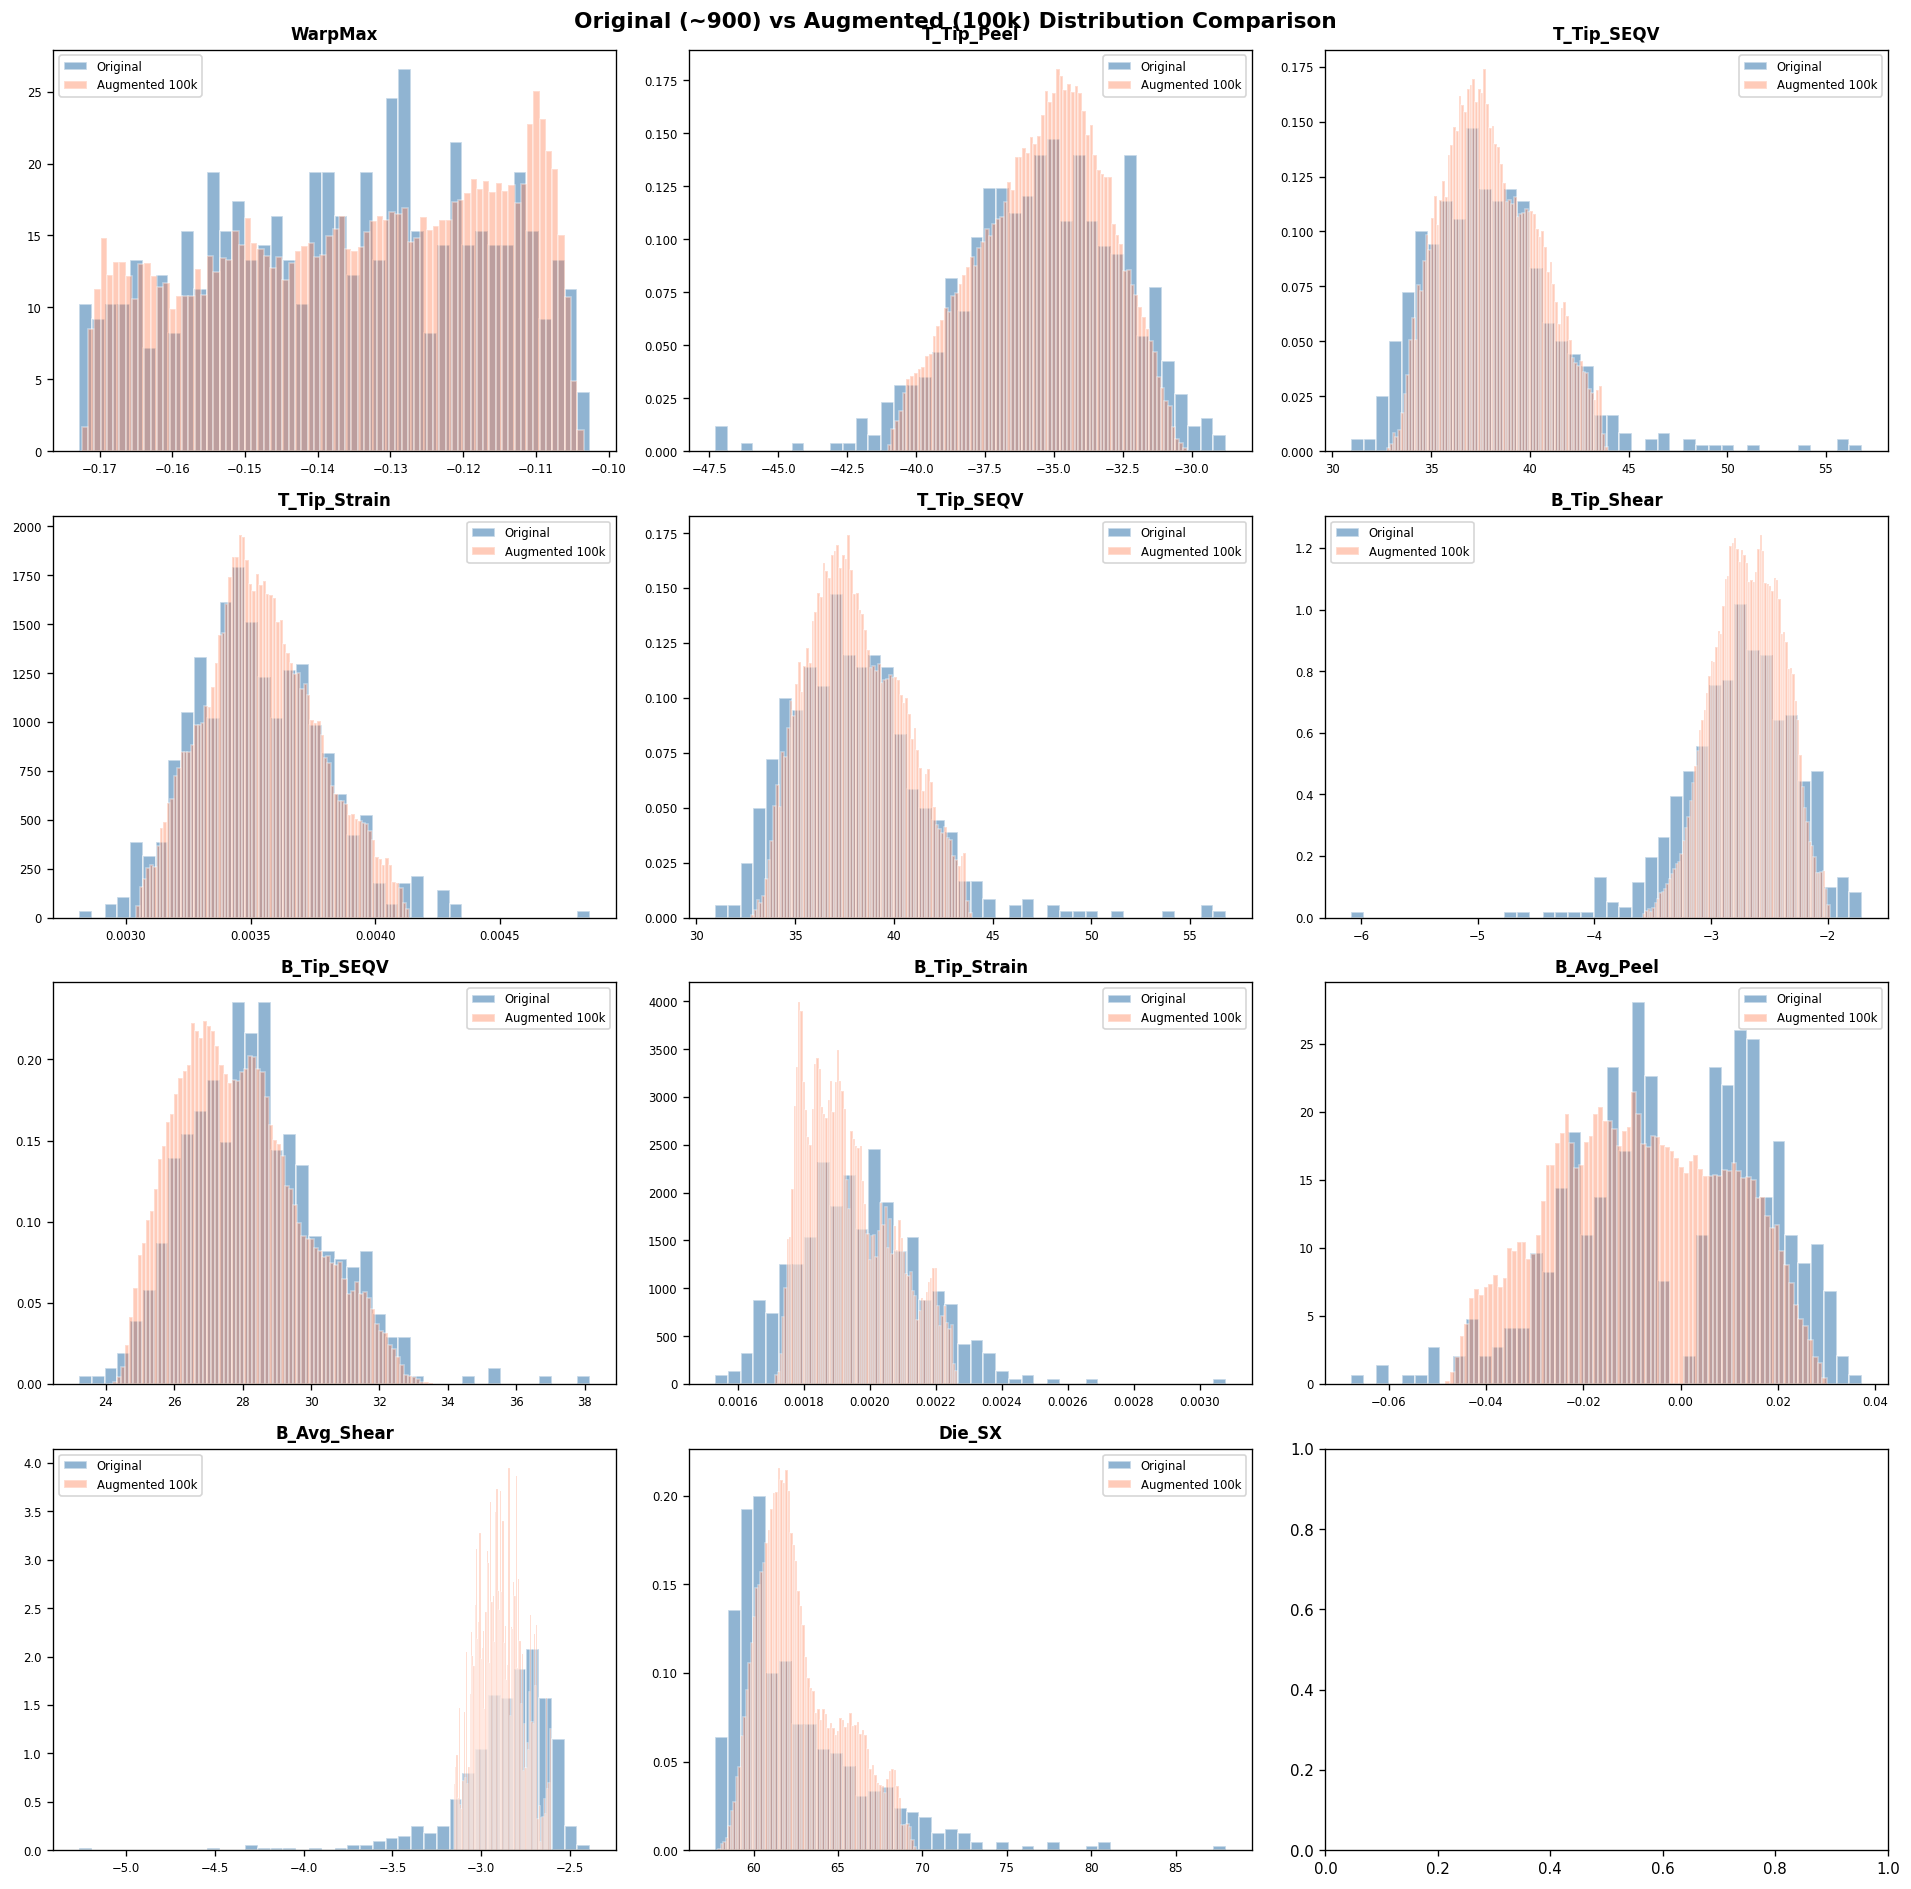

* 분포가 대체로 일치하면 -> 대리 모델이 원본 경향을 잘 학습한 것
* 분포가 크게 다르면 -> 과적합/외삽 위험 -> 하이퍼파라미터 재조정 필요


In [24]:
# == 6-1. 원본 vs 증강 분포 비교 (주요 6개 변수) ==

check_cols = ['WarpMax', 'T_Tip_Peel', 'T_Tip_SEQV', 'T_Tip_Strain',
              'T_Tip_SEQV', 'B_Tip_Shear', 'B_Tip_SEQV', 'B_Tip_Strain', 'B_Avg_Peel', 'B_Avg_Shear', 'Die_SX']

fig, axes = plt.subplots(4, 3, figsize=(16, 16))
fig.suptitle('Original (~900) vs Augmented (100k) Distribution Comparison',
             fontsize=13, fontweight='bold')

for idx, y_col in enumerate(check_cols):
    ax = axes[idx // 3, idx % 3]
    
    # 원본 데이터 분포 (파란색 히스토그램)
    ax.hist(df_peaks[y_col], bins=40, density=True, alpha=0.6,
            color='steelblue', edgecolor='white', label='Original')
    
    # 증강 데이터 분포 (빨간색 히스토그램, 더 세밀한 bin)
    ax.hist(df_augmented[y_col], bins=80, density=True, alpha=0.4,
            color='coral', edgecolor='white', label='Augmented 100k')
    
    ax.set_title(y_col, fontweight='bold', fontsize=10)
    ax.legend(fontsize=7)
    ax.tick_params(labelsize=7)

plt.tight_layout()
plt.show()

print('* 분포가 대체로 일치하면 -> 대리 모델이 원본 경향을 잘 학습한 것')
print('* 분포가 크게 다르면 -> 과적합/외삽 위험 -> 하이퍼파라미터 재조정 필요')

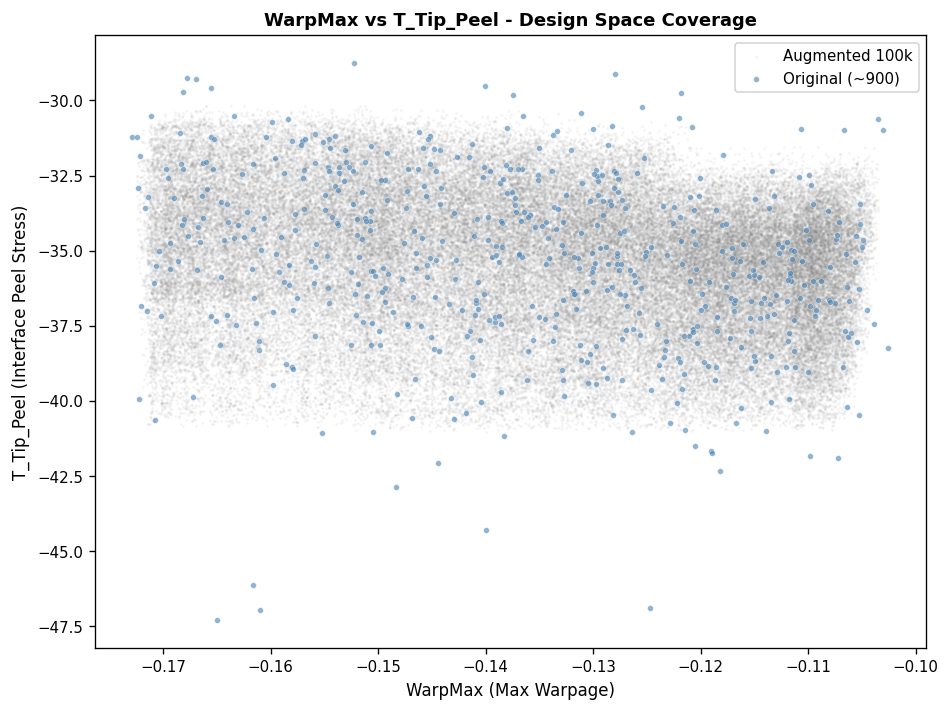

-> 이 2D 공간에서 좌측 하단(WarpMax 작고, T_Tip_Peel 작은)이 이상적인 설계
-> Step 3에서 파레토 프론티어(비지배 해 집합)를 추출할 영역


In [25]:
# == 6-2. 메인 타겟 2D 산점도 (WarpMax vs T_Tip_Peel) ==
# Step 3 파레토 프론티어에서 사용할 두 축의 공간 분포 확인

fig, ax = plt.subplots(figsize=(8, 6))

# 증강 데이터 (배경: 회색, 매우 투명하게)
ax.scatter(df_augmented['WarpMax'], df_augmented['T_Tip_Peel'],
           s=1, alpha=0.05, c='gray', label='Augmented 100k')

# 원본 데이터 (전경: 파란색, 선명하게)
ax.scatter(df_peaks['WarpMax'], df_peaks['T_Tip_Peel'],
           s=12, alpha=0.6, c='steelblue', edgecolors='white',
           linewidths=0.3, label='Original (~900)')

ax.set_xlabel('WarpMax (Max Warpage)', fontsize=10)
ax.set_ylabel('T_Tip_Peel (Interface Peel Stress)', fontsize=10)
ax.set_title('WarpMax vs T_Tip_Peel - Design Space Coverage', fontweight='bold')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

print('-> 이 2D 공간에서 좌측 하단(WarpMax 작고, T_Tip_Peel 작은)이 이상적인 설계')
print('-> Step 3에서 파레토 프론티어(비지배 해 집합)를 추출할 영역')

---
## Step 1 완료 요약

| 항목 | 결과 |
|------|------|
| 원본 생존 데이터 | ~900개 DP (1200 중 ~71%) |
| 추출 지표 | 15개 Y변수의 절댓값 Max Peak (부호 유지) |
| 대리 모델 | 타겟별 개별 XGBoost (Early Stopping + 5-Fold CV) |
| 증강 데이터 | **100,000개** (`Augmented_100k_Data.csv`) |
| 난수 생성 | Latin Hypercube Sampling (균등 공간 충전) |

### 다음 단계
-> **[Step 2: Gatekeeper 분류기]** 에서 증강된 10만 개 중 '물리적으로 파괴되는 조합'을 필터링합니다.

In [41]:
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C, WhiteKernel, DotProduct
import pandas as pd
import numpy as np

# == 6-1. 신뢰도 검증을 위한 후보군 선별 ==
# 모든 데이터를 다 검증하기엔 시간이 오래 걸리므로, 
# LGBM 예측 기준 WarpMax와 T_Tip_Peel이 낮은 상위 5,000개를 먼저 뽑습니다.
candidates = df_virtual_Y.nsmallest(5000, 'WarpMax').index
X_candidates = df_virtual_X.loc[candidates]
Y_candidates_lgbm = df_virtual_Y.loc[candidates]

# == 6-2. GBR + ARD 모델 정의 및 학습 ==
# ARD 커널 설정: 각 입력 변수(P1~P6)의 가중치를 독립적으로 학습합니다.
kernel = C(1.0, (1e-3, 1e3)) * RBF(length_scale=[1.0]*6, length_scale_bounds=(1e-2, 1e2)) \
         + WhiteKernel(noise_level=1e-5, noise_level_bounds=(1e-10, 1e+1))

# 메인 타겟인 WarpMax에 대해 신뢰도 모델 학습 (데이터 효율을 위해 원본 df_peaks 사용)
gpr = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=10, random_state=SEED)

print("GBR 모델 학습 중 (신뢰도 분석)...")
gpr.fit(X_train, Y_train['WarpMax']) # 원본 학습 데이터로 학습

# == 6-3. 후보군에 대한 예측 및 불확실성(Standard Deviation) 계산 ==
# return_std=True 옵션이 GBR의 핵심입니다.
y_pred_gbr, y_std = gpr.predict(X_candidates, return_std=True)

# == 6-4. 신뢰도 기반 필터링 (95% 신뢰 구간 활용) ==
# 불확실성(std)이 작을수록 AI가 확신하는 데이터입니다.
df_reliability = pd.DataFrame({
    'WarpMax_Pred': y_pred_gbr,
    'Uncertainty_Std': y_std,
    'Confidence_Interval_Upper': y_pred_gbr + 1.96 * y_std # 95% 신뢰구간 상한
}, index=candidates)

# AI가 예측한 값도 낮고, 예측의 불확실성(Std)도 낮은 데이터만 필터링
# (예: 전체 후보 중 불확실성 하위 50%만 남김)
std_threshold = df_reliability['Uncertainty_Std'].quantile(0.5)
safe_indices = df_reliability[df_reliability['Uncertainty_Std'] <= std_threshold].index

df_safe_X = df_virtual_X.loc[safe_indices]
df_safe_Y = df_virtual_Y.loc[safe_indices]

print(f"최종 필터링 완료: {len(df_safe_X)}개의 안전 설계안 확보")

GBR 모델 학습 중 (신뢰도 분석)...
최종 필터링 완료: 2500개의 안전 설계안 확보


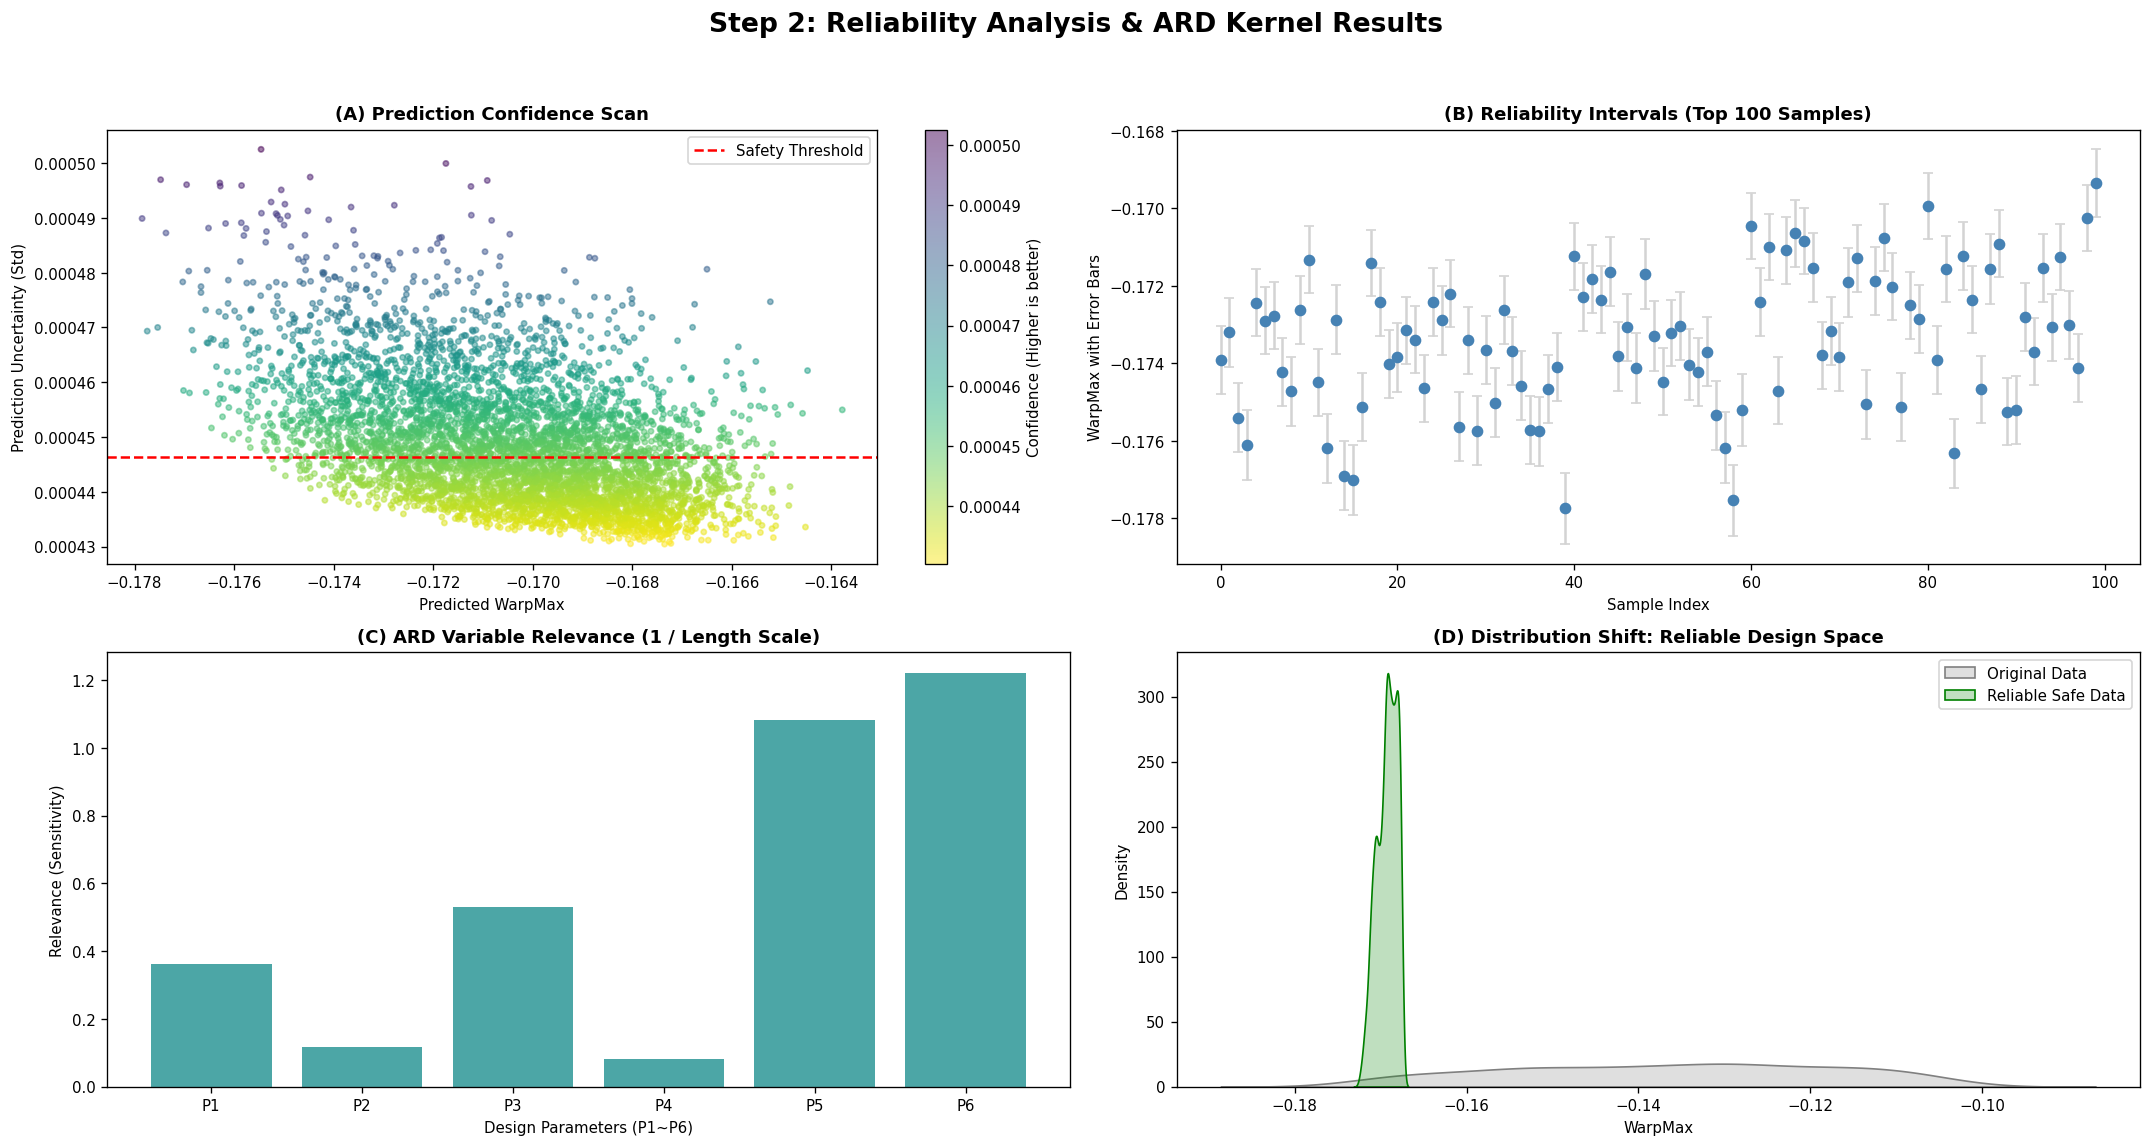

In [42]:
import matplotlib.pyplot as plt
import seaborn as sns

# == 6-2. GBR 신뢰도 및 ARD 커널 결과 시각화 ==
fig = plt.figure(figsize=(18, 10))
plt.suptitle('Step 2: Reliability Analysis & ARD Kernel Results', fontsize=16, fontweight='bold')

# (A) 예측값 vs 불확실성 (Uncertainty Scan)
# - X축: 예측된 WarpMax, Y축: 모델의 불확실성(Std)
ax1 = fig.add_subplot(2, 2, 1)
sc = ax1.scatter(df_reliability['WarpMax_Pred'], df_reliability['Uncertainty_Std'], 
                 c=df_reliability['Uncertainty_Std'], cmap='viridis_r', alpha=0.5, s=10)
ax1.axhline(std_threshold, color='red', linestyle='--', label='Safety Threshold')
ax1.set_xlabel('Predicted WarpMax')
ax1.set_ylabel('Prediction Uncertainty (Std)')
ax1.set_title('(A) Prediction Confidence Scan', fontweight='bold')
ax1.legend()
plt.colorbar(sc, ax=ax1, label='Confidence (Higher is better)')

# (B) 95% 신뢰구간 시각화 (상위 100개 샘플)
# - 실제 예측값이 신뢰구간 안에 어떻게 위치하는지 확인
ax2 = fig.add_subplot(2, 2, 2)
sample_df = df_reliability.head(100).reset_index()
ax2.errorbar(sample_df.index, sample_df['WarpMax_Pred'], 
             yerr=1.96 * sample_df['Uncertainty_Std'], fmt='o', ecolor='lightgray', 
             mfc='steelblue', mec='steelblue', capsize=3, label='95% Confidence Interval')
ax2.set_title('(B) Reliability Intervals (Top 100 Samples)', fontweight='bold')
ax2.set_xlabel('Sample Index')
ax2.set_ylabel('WarpMax with Error Bars')

# (C) ARD 커널 변수 중요도 (Length Scales)
# - Length Scale이 짧을수록(작을수록) 해당 변수가 결과에 미치는 영향이 큼(민감함)
ax3 = fig.add_subplot(2, 2, 3)
# gpr.kernel_.get_params()에서 RBF 커널의 length_scale 추출
ls = gpr.kernel_.get_params()['k1__k2__length_scale']
p_labels = ['P1', 'P2', 'P3', 'P4', 'P5', 'P6']

# 영향도(Relevance)로 변환 (1/LengthScale) - 시각적으로 직관적이게 함
relevance = 1.0 / np.array(ls)
ax3.bar(p_labels, relevance, color='teal', alpha=0.7)
ax3.set_title('(C) ARD Variable Relevance (1 / Length Scale)', fontweight='bold')
ax3.set_ylabel('Relevance (Sensitivity)')
ax3.set_xlabel('Design Parameters (P1~P6)')

# (D) 최종 필터링된 데이터의 분포 (Safe vs Original)
ax4 = fig.add_subplot(2, 2, 4)
sns.kdeplot(df_peaks['WarpMax'], label='Original Data', fill=True, color='gray', ax=ax4)
sns.kdeplot(df_safe_Y['WarpMax'], label='Reliable Safe Data', fill=True, color='green', ax=ax4)
ax4.set_title('(D) Distribution Shift: Reliable Design Space', fontweight='bold')
ax4.set_xlabel('WarpMax')
ax4.legend()

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

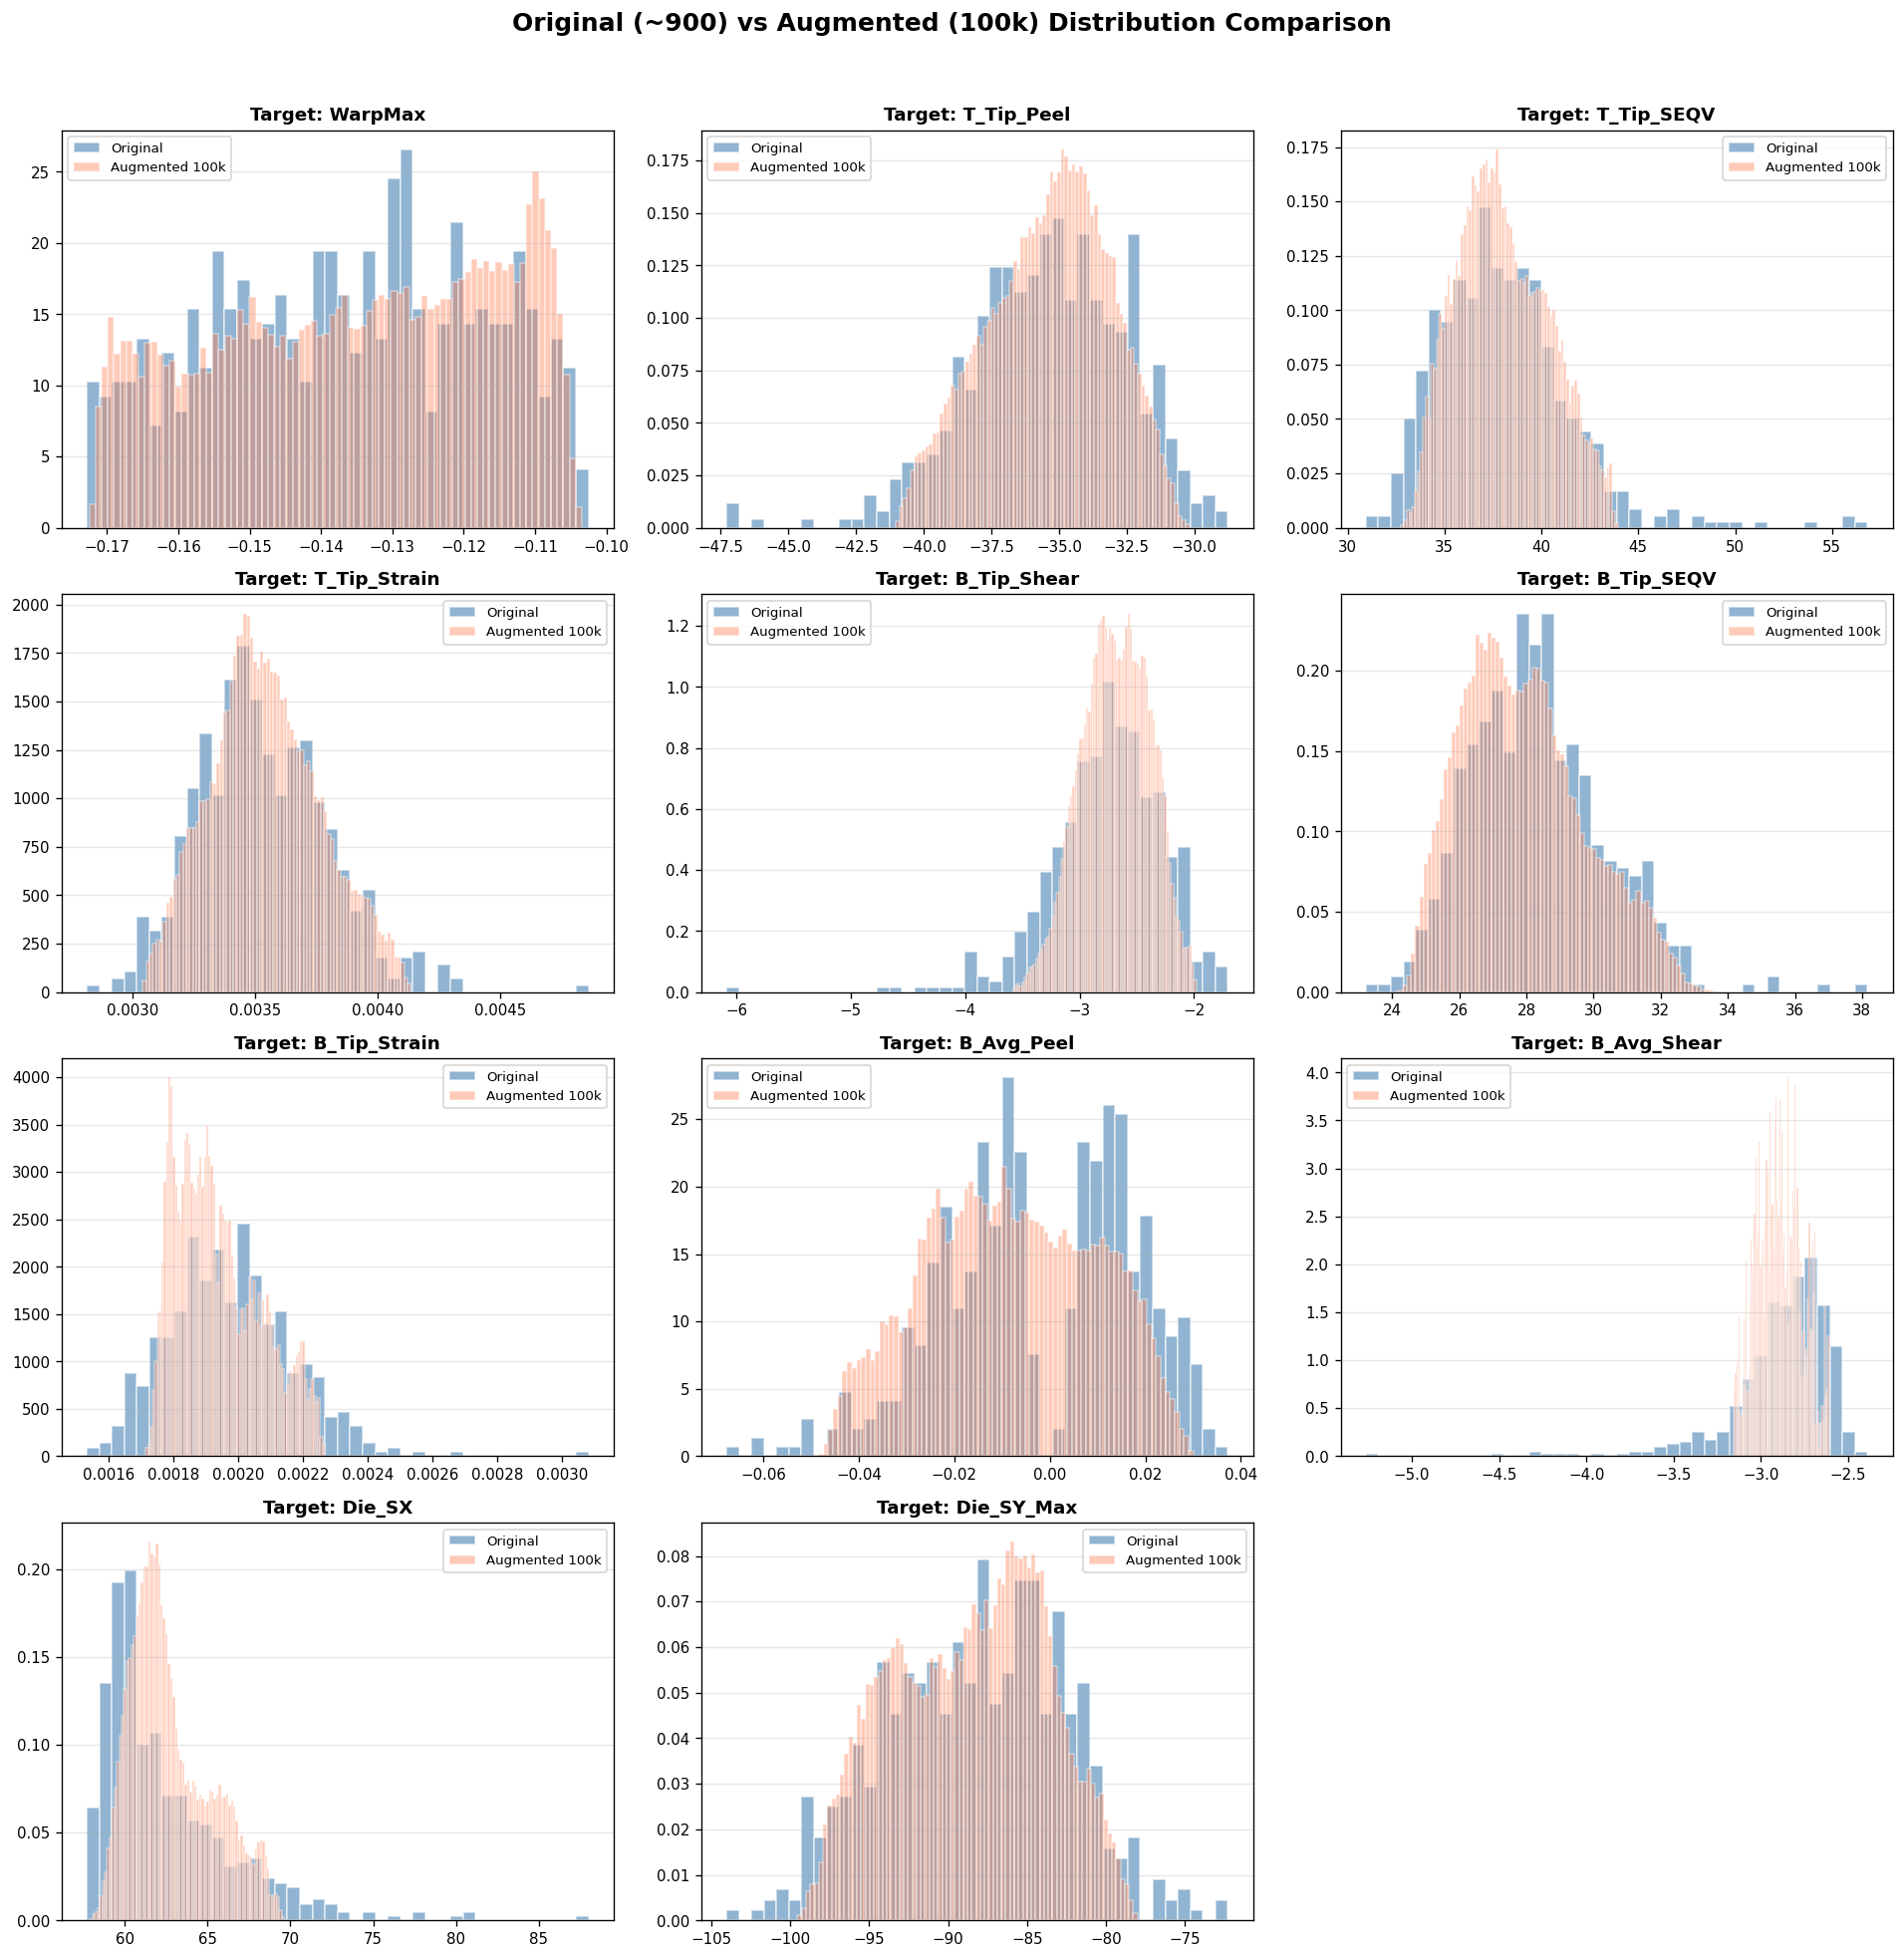

✅ 총 11개 변수에 대한 분포 비교가 완료되었습니다.


In [43]:
import math

# 1. 시각화할 컬럼 리스트 (학습에 실제 사용된 11개 변수)
check_cols = Y_COLUMNS_FILTERED 

# 2. 레이아웃 설정 (자동으로 행/열 개수 계산)
n_cols = 3
n_rows = math.ceil(len(check_cols) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 4 * n_rows))
fig.suptitle('Original (~900) vs Augmented (100k) Distribution Comparison',
             fontsize=15, fontweight='bold', y=1.02)

# axes가 2차원 배열일 경우를 대비해 1차원으로 평탄화
axes_flat = axes.flatten()

for idx, y_col in enumerate(check_cols):
    ax = axes_flat[idx]
    
    # 원본 데이터 분포 (파란색)
    ax.hist(df_peaks[y_col], bins=40, density=True, alpha=0.6,
            color='steelblue', edgecolor='white', label='Original')
    
    # 증강 데이터 분포 (주황색) - df_virtual_Y 사용
    ax.hist(df_virtual_Y[y_col], bins=80, density=True, alpha=0.4,
            color='coral', edgecolor='white', label='Augmented 100k')
    
    ax.set_title(f'Target: {y_col}', fontweight='bold', fontsize=11)
    ax.legend(fontsize=8)
    ax.grid(axis='y', alpha=0.3)

# 남는 빈 칸(그래프) 삭제
for j in range(idx + 1, len(axes_flat)):
    fig.delaxes(axes_flat[j])

plt.tight_layout()
plt.show()

print(f'✅ 총 {len(check_cols)}개 변수에 대한 분포 비교가 완료되었습니다.')

In [ ]:
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C, WhiteKernel
import pandas as pd
import numpy as np

# == 1. 신뢰도 검증을 위한 상위 후보군 선별 (Top 5,000) ==
# WarpMax와 T_Tip_Peel이 동시에 낮은 '우수 후보'를 먼저 추출합니다.
# (두 변수의 합산 순위 등을 활용하여 상위 5,000개를 선정)
candidates_idx = (df_virtual_Y['WarpMax'] + df_virtual_Y['T_Tip_Peel']).nsmallest(5000).index
X_candidates = df_virtual_X.loc[candidates_idx]
Y_candidates_lgbm = df_virtual_Y.loc[candidates_idx]

# == 2. GBR + ARD 모델 정의 및 학습 ==
# ARD 커널: length_scale을 리스트로 주어 P1~P6의 중요도를 개별 학습하게 합니다.
kernel = C(1.0, (1e-3, 1e3)) * RBF(length_scale=[1.0]*6, length_scale_bounds=(1e-2, 1e2)) \
         + WhiteKernel(noise_level=1e-5, noise_level_bounds=(1e-10, 1e+1))

# 가장 중요한 지표인 WarpMax를 기준으로 신뢰도 모델 학습
gpr = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=5, random_state=SEED)

print("GBR 신뢰도 모델 학습 중... (약 1~2분 소요)")
gpr.fit(X_train, Y_train['WarpMax']) 

# == 3. 후보군에 대한 정밀 예측 및 불확실성(표준편차) 계산 ==
# return_std=True가 신뢰도 필터링의 핵심입니다.
y_pred_gbr, y_std = gpr.predict(X_candidates, return_std=True)

# == 4. 신뢰도 기반 최종 필터링 (95% 신뢰구간 적용) ==
df_reliability = pd.DataFrame({
    'WarpMax_Pred': y_pred_gbr,
    'Uncertainty_Std': y_std,
    'Upper_95': y_pred_gbr + (1.96 * y_std) # 통계적 상한선
}, index=candidates_idx)

# 필터링 조건: 예측값의 95% 상한선이 전체 평균보다 낮은 '확실한 안전군'만 추출
reliability_threshold = df_reliability['Uncertainty_Std'].quantile(0.5) # 불확실성 하위 50% 선별
safe_indices = df_reliability[df_reliability['Uncertainty_Std'] <= reliability_threshold].index

df_safe_X = df_virtual_X.loc[safe_indices]
df_safe_Y = df_virtual_Y.loc[safe_indices]

print(f"✅ 필터링 완료: 10만 개 중 {len(df_safe_X)}개의 '신뢰 가능한 안전 설계안' 확보")

GBR 신뢰도 모델 학습 중... (약 1~2분 소요)
✅ 필터링 완료: 10만 개 중 2500개의 '신뢰 가능한 안전 설계안' 확보


<Figure size 768x576 with 0 Axes>

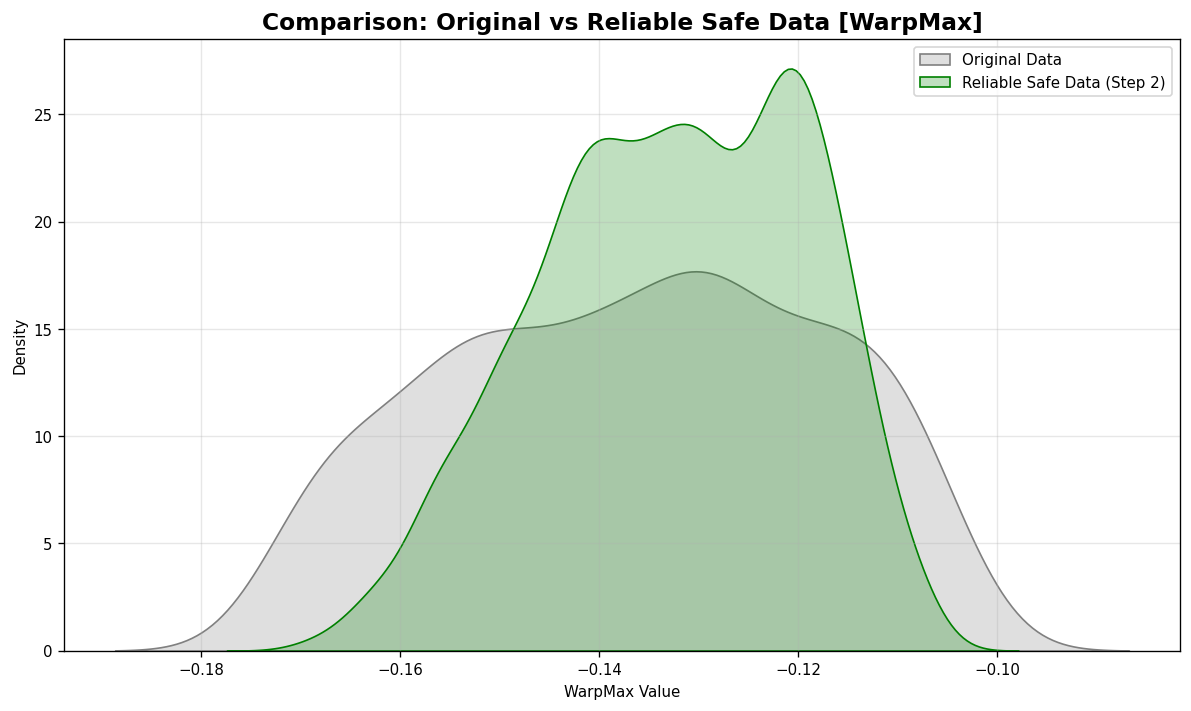

In [47]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 비교할 타겟 변수 설정 (예: WarpMax)
target_col = 'WarpMax' 

# 2. 도화지 생성
fig, ax = plt.subplots(figsize=(10, 6))

# 3. 원본 데이터 분포 (회색)
sns.kdeplot(df_peaks[target_col], fill=True, color='gray', label='Original Data', ax=ax)

# 4. 필터링된 안전 데이터 분포 (초록색)
# df_safe_Y가 생성되어 있어야 합니다.
sns.kdeplot(df_safe_Y[target_col], fill=True, color='green', label='Reliable Safe Data (Step 2)', ax=ax)

# 5. 그래프 꾸미기
ax.set_title(f'Comparison: Original vs Reliable Safe Data [{target_col}]', fontsize=14, fontweight='bold')
ax.set_xlabel(f'{target_col} Value')
ax.set_ylabel('Density')
ax.legend()
ax.grid(True, alpha=0.3)

# 6. 강제 출력 명령
plt.tight_layout()
plt.show()

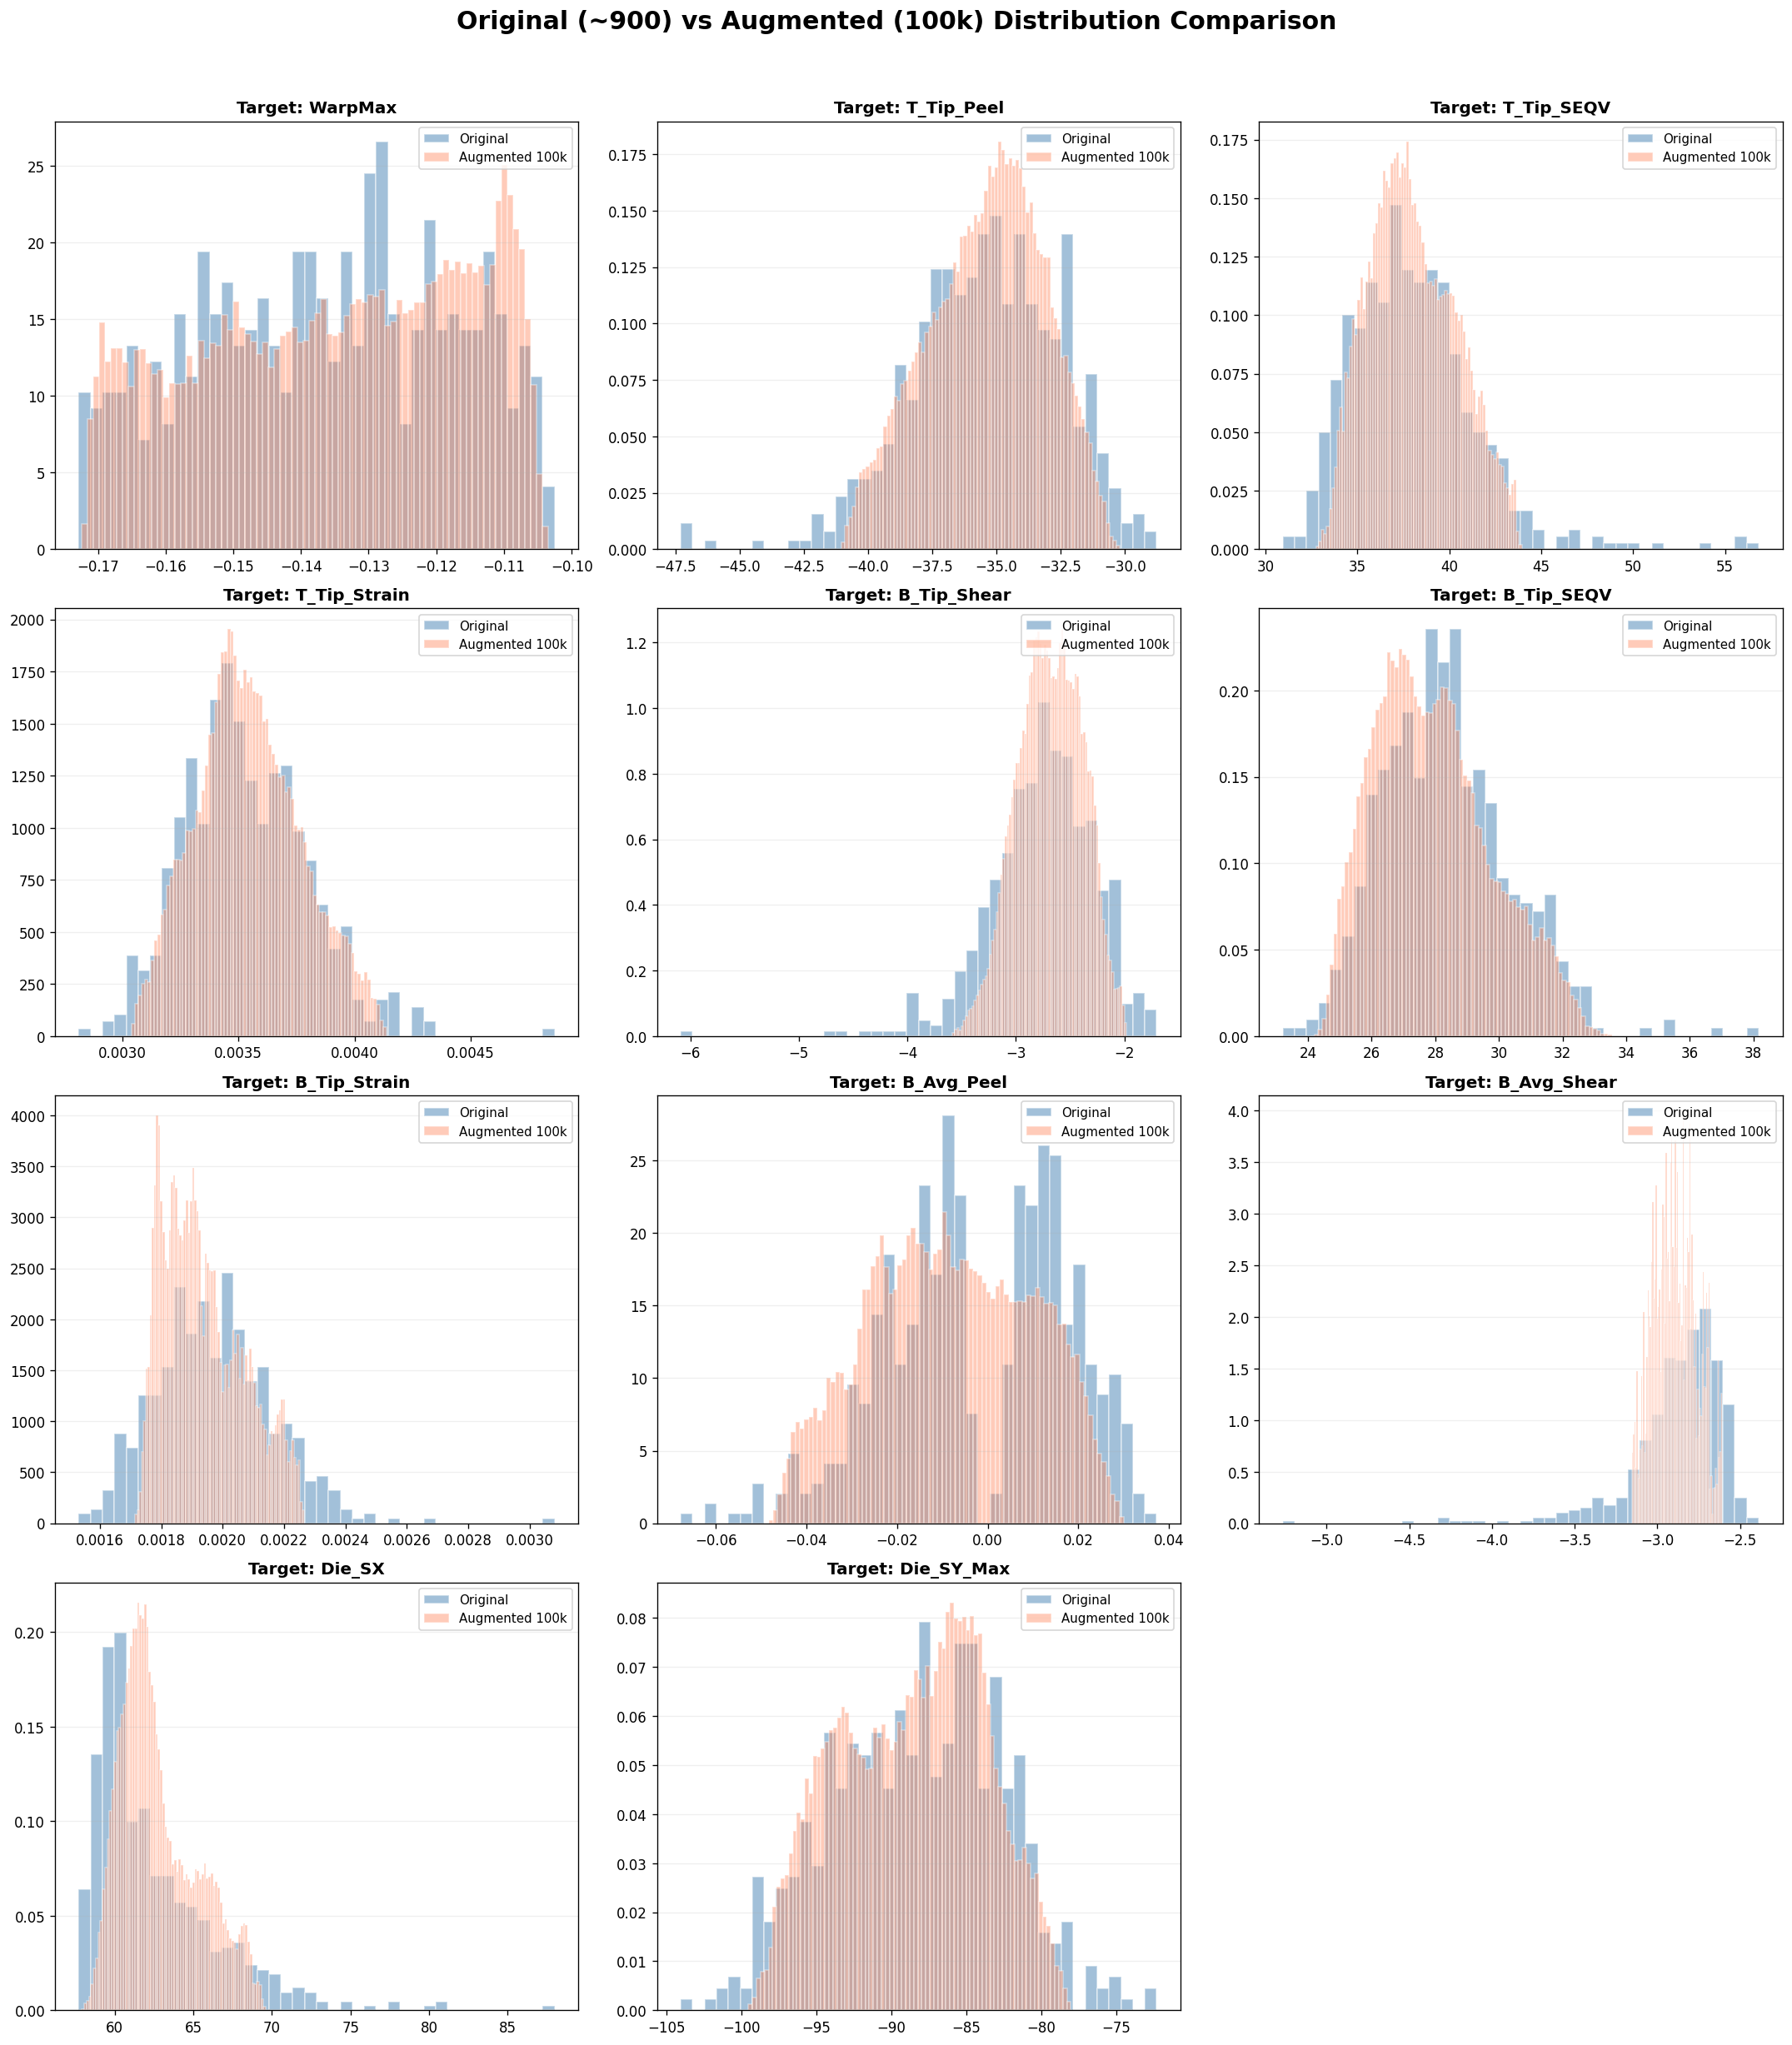

In [48]:
import matplotlib.pyplot as plt
import math

# 1. 시각화 대상 리스트 확인 (제외된 4개 제외, 남은 11개)
check_cols = Y_COLUMNS_FILTERED 

# 2. 레이아웃 설정 (4행 3열)
n_cols = 3
n_rows = math.ceil(len(check_cols) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 5 * n_rows))
fig.suptitle('Original (~900) vs Augmented (100k) Distribution Comparison', 
             fontsize=18, fontweight='bold', y=1.02)

# 1차원 배열로 평탄화하여 반복문 돌리기 편하게 설정
axes_flat = axes.flatten()

for idx, y_col in enumerate(check_cols):
    ax = axes_flat[idx]
    
    # 원본 데이터 (파란색 히스토그램)
    ax.hist(df_peaks[y_col], bins=40, density=True, alpha=0.5, 
            color='steelblue', edgecolor='white', label='Original')
    
    # 증강 데이터 (주황색 히스토그램 - df_virtual_Y 사용)
    ax.hist(df_virtual_Y[y_col], bins=80, density=True, alpha=0.4, 
            color='coral', edgecolor='white', label='Augmented 100k')
    
    # 타이틀 및 꾸미기
    ax.set_title(f'Target: {y_col}', fontweight='bold', fontsize=12)
    ax.legend(fontsize=9, loc='upper right')
    ax.grid(axis='y', alpha=0.2)
    ax.tick_params(labelsize=10)

# 11개일 경우 마지막 12번째 빈 칸 삭제
if len(axes_flat) > len(check_cols):
    for j in range(len(check_cols), len(axes_flat)):
        fig.delaxes(axes_flat[j])

plt.tight_layout()
plt.show()

🎯 파레토 최적 설계안 발견: 15개

🚀 [Step 4 입력용] 유토피아 타겟 수치:
- 목표 WarpMax: -0.1411
- 목표 T_Tip_Peel: -30.2579


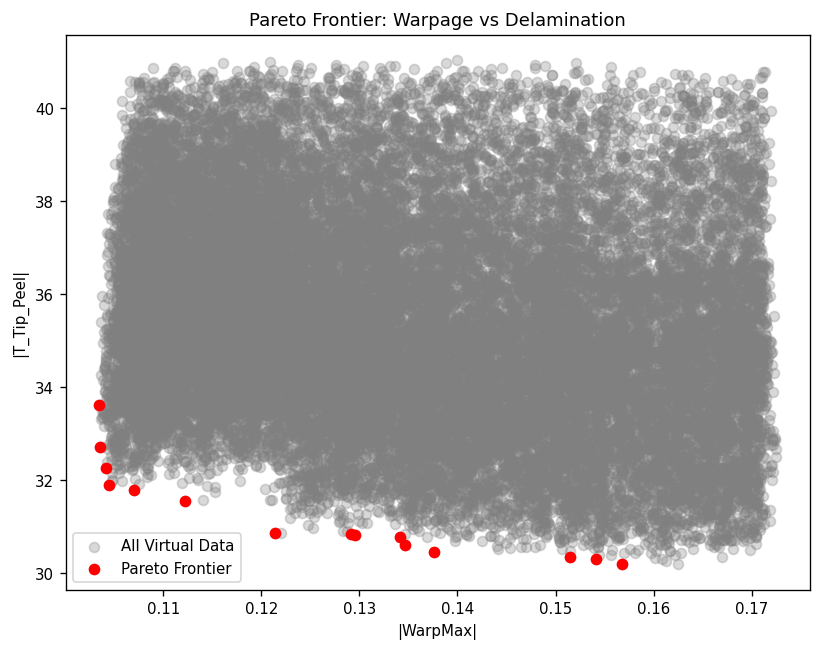

In [39]:
import numpy as np
import matplotlib.pyplot as plt

def is_pareto_efficient(costs):
    """
    파레토 효율적인 지점(비지배 해)을 찾는 함수
    costs: (n_samples, n_objectives) 형태의 어레이
    """
    is_efficient = np.ones(costs.shape[0], dtype=bool)
    for i, c in enumerate(costs):
        if is_efficient[i]:
            # 현재 포인트보다 모든 목표에서 더 나은(작은) 포인트가 있는지 확인
            is_efficient[is_efficient] = np.any(costs[is_efficient] < c, axis=1)
            is_efficient[i] = True
    return is_efficient

# 1. 타겟 지표 추출 및 절댓값 처리
# README 가이드: WarpMax와 T_Tip_Peel 단 2가지만 기준으로 선별
# 최소화(Minimize) 문제이므로 절댓값을 취해 0에 가까운 것을 찾습니다.
target_metrics = df_filtered_virtual[['WarpMax', 'T_Tip_Peel']].abs().values

# 2. 파레토 최적점 계산
pareto_mask = is_pareto_efficient(target_metrics)
df_pareto = df_filtered_virtual[pareto_mask].copy()

print(f"🎯 파레토 최적 설계안 발견: {len(df_pareto)}개")

# 3. 유토피아 타겟(Utopia Target) 설정
# 가이드: 선정된 파레토 DP 중 최상위 성능에서 10% 더 개선(x0.9)한 수치
target_warpage = df_pareto['WarpMax'].min() * 0.9
target_peel = df_pareto['T_Tip_Peel'].min() * 0.9

print(f"\n🚀 [Step 4 입력용] 유토피아 타겟 수치:")
print(f"- 목표 WarpMax: {target_warpage:.4f}")
print(f"- 목표 T_Tip_Peel: {target_peel:.4f}")

# 4. 시각화 (선택 사항)
plt.figure(figsize=(8, 6))
plt.scatter(df_filtered_virtual['WarpMax'].abs(), df_filtered_virtual['T_Tip_Peel'].abs(), 
            c='gray', alpha=0.3, label='All Virtual Data')
plt.scatter(df_pareto['WarpMax'].abs(), df_pareto['T_Tip_Peel'].abs(), 
            c='red', label='Pareto Frontier')
plt.xlabel('|WarpMax|')
plt.ylabel('|T_Tip_Peel|')
plt.title('Pareto Frontier: Warpage vs Delamination')
plt.legend()
plt.show()

In [40]:
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.preprocessing import StandardScaler

# 1. 데이터 준비 (Step 1의 10만개 증강 데이터 활용)
# 입력(X_inv): 예측된 Y 지표들 (WarpMax, T_Tip_Peel 등)
# 출력(y_inv): 원본 설계 변수 (P1 ~ P6)
X_inv_data = df_augmented[['WarpMax', 'T_Tip_Peel']].values
y_inv_data = df_augmented[['P1', 'P2', 'P3', 'P4', 'P5', 'P6']].values

# 스케일링 (딥러닝 모델의 수렴을 위해 필수)
scaler_X = StandardScaler()
scaler_y = StandardScaler()

X_inv_scaled = scaler_X.fit_transform(X_inv_data)
y_inv_scaled = scaler_y.fit_transform(y_inv_data)

# PyTorch 텐서 변환
X_tensor = torch.FloatTensor(X_inv_scaled)
y_tensor = torch.FloatTensor(y_inv_scaled)

# 2. 역설계 신경망 정의
class InverseNet(nn.Module):
    def __init__(self):
        super(InverseNet, self).__init__()
        self.layers = nn.Sequential(
            nn.Linear(2, 64), # 입력: WarpMax, T_Tip_Peel
            nn.ReLU(),
            nn.Linear(64, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 6)   # 출력: P1 ~ P6
        )
        
    def forward(self, x):
        return self.layers(x)

model_inv = InverseNet()
criterion = nn.MSELoss()
optimizer = optim.Adam(model_inv.parameters(), lr=0.001)

# 3. 모델 학습
print("역설계 모델 학습 시작...")
for epoch in range(100):
    optimizer.zero_grad()
    outputs = model_inv(X_tensor)
    loss = criterion(outputs, y_tensor)
    loss.backward()
    optimizer.step()
    if (epoch+1) % 20 == 0:
        print(f"Epoch [{epoch+1}/100], Loss: {loss.item():.4f}")

# 4. 유토피아 타겟을 이용한 최적 P1~P6 초안(Draft) 도출
utopia_input = np.array([[target_warpage, target_peel]])
utopia_input_scaled = scaler_X.transform(utopia_input)
utopia_tensor = torch.FloatTensor(utopia_input_scaled)

model_inv.eval()
with torch.no_grad():
    predicted_P_scaled = model_inv(utopia_tensor).numpy()

# 스케일링 복원 (실제 mm 단위 두께로 변환)
predicted_P = scaler_y.inverse_transform(predicted_P_scaled)

print("\n✨ [Step 4 결과] 유토피아 타겟을 만족하는 최적 설계 초안(Draft):")
p_names = ['P1(Sub)', 'P2(UF)', 'P3(Die)', 'P4(Adh)', 'P5(IHS)', 'P6(TIM)']
for name, val in zip(p_names, predicted_P[0]):
    print(f"- {name}: {val:.4f} mm")

역설계 모델 학습 시작...
Epoch [20/100], Loss: 0.7252
Epoch [40/100], Loss: 0.6789
Epoch [60/100], Loss: 0.6744
Epoch [80/100], Loss: 0.6719
Epoch [100/100], Loss: 0.6700

✨ [Step 4 결과] 유토피아 타겟을 만족하는 최적 설계 초안(Draft):
- P1(Sub): 0.8101 mm
- P2(UF): 0.0867 mm
- P3(Die): 0.6539 mm
- P4(Adh): 0.2190 mm
- P5(IHS): 1.4139 mm
- P6(TIM): 0.0702 mm
